# Problem Statement
## Business Context:
FicZon Inc., an IT solutions provider, generates most of its leads digitally through its website. Sales performance is heavily dependent on lead quality and the effectiveness of its sales team. Currently, lead categorization into high and low potential is manual, which slows down response time and reduces sales efficiency.

## Problem:
The current manual process is not scalable, inconsistent, and provides value mainly for post-analysis rather than real-time decision-making. With a maturing market and increasing competition, FicZon is experiencing a dip in sales.

## Objective:
Build a Machine Learning model to predict lead category (High Potential vs Low Potential) based on historical lead data. The model should:

Automate pre-categorization of leads

Increase sales conversion by routing high-potential leads to the right sales agents

Provide actionable insights for marketing and sales strategy

## ML Problem Type:

Supervised classification problem

Target variable: Status (or transformed as High Potential / Low Potential)

Evaluation metrics: Accuracy, Precision, Recall, F1-score (focus on correctly identifying High Potential leads)


# Feature Analysis for FicZon Lead Quality Prediction

## 1. Dataset Overview
The dataset contains 7422 entries and the following columns:

| Feature | Type | Missing Values | Description |
|---------|------|----------------|------------|
| Created | Datetime | 0 | Lead creation timestamp |
| Product_ID | Numerical / Categorical | 58 | Product associated with the lead |
| Source | Categorical | 17 | Lead acquisition channel |
| Mobile | Categorical / Identifier | 1810 | Lead mobile number |
| EMAIL | Text / Categorical | 0 | Lead email address |
| Sales_Agent | Categorical | 23 | Agent handling the lead |
| Location | Categorical | 58 | Lead geographical location |
| Delivery_Mode | Categorical | 0 | Mode of product delivery |
| Status | Categorical / Target | 0 | Lead status (CONVERTED / others) |

---

## 2. Feature Analysis

### Created
- Convert to datetime format.
- Extract features such as day, month, weekday, and hour.
- Can capture temporal trends in lead conversions.
### Product_ID

Represents the product associated with the lead.
Missing values (~58) can be imputed or treated as a separate category.

Can indicate product-specific lead patterns.

### Source

Categorical feature indicating lead acquisition channel (e.g., website, digital campaigns).

Can be encoded using one-hot or target encoding.

Top-performing sources may be predictive of high-quality leads.


### Mobile

Missing mobile numbers (~1810) may indicate lower-quality leads.

Can create a derived feature: has_mobile = 1 if Mobile exists else 0.


### EMAIL

Extract the domain to create Email_Domain feature.

Helps differentiate corporate vs public leads.


### Sales_Agent

Agent effectiveness is predictive of lead conversion.

Can calculate agent-wise historical conversion percentage.

### Location

Certain locations consistently generate high-quality leads.

Can be encoded as categorical or grouped into top-performing vs low-performing locations.


### Delivery_Mode

Some delivery modes may produce better conversion rates.

Encode using one-hot or label encoding.


### Status (Target)

Target variable for binary classification: High Potential vs Low Potential.

Clean inconsistencies in casing:




# 1. Installing and Importing Libraries

In [1]:
# installing libraries
%pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
print(sys.version)

3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]


In [3]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

import warnings 
warnings.filterwarnings('ignore')

# 2. Loading Dataset and performing basic checks

In [4]:
# connecting to the database server
connection = mysql.connector.connect(host ='18.136.157.135',
                                    user ='dm_team2',
                                    password ='DM!$Team&27@9!20!',
                                    database ='project_sales',
                                    port = '3306')

In [5]:
# Loading the dataset from database server
df = pd.read_sql("select * from data",connection)

# checking head of the data
df.head()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,,Mode-5,Open
1,14-11-2018 09:22,,Website,XXXXXXX,#VALUE!,Sales-Agent-10,,Mode-5,Open
2,14-11-2018 09:21,,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,,Mode-5,Open
3,14-11-2018 08:46,,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open
4,14-11-2018 07:34,,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open


In [6]:
# checking tail of the data
df.tail()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
7417,28-04-2018 09:45,9,Call,,aXXXXXXX@gmail.com,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,28-04-2018 09:43,15,Call,,#VALUE!,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,28-04-2018 09:20,5,Live Chat-Direct,,sXXXXXXX@gmail.com,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,28-04-2018 08:04,21,CRM form,,YXXXXXXX@gmail.com,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry
7421,28-04-2018 07:54,25,Website,,cXXXXXXX@gmail.com,Sales-Agent-3,Chennai,Mode-1,CONVERTED


In [7]:
# checking the columns names
df.columns

Index(['Created', 'Product_ID', 'Source', 'Mobile', 'EMAIL', 'Sales_Agent',
       'Location', 'Delivery_Mode', 'Status'],
      dtype='object')

In [8]:
# Checking shape of the dataframe
df.shape

(7422, 9)

In [9]:
# Checking data types of the dataframe
df.dtypes

Created          object
Product_ID       object
Source           object
Mobile           object
EMAIL            object
Sales_Agent      object
Location         object
Delivery_Mode    object
Status           object
dtype: object

In [10]:
# Checking general information about dataframe 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422 entries, 0 to 7421
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Created        7422 non-null   object
 1   Product_ID     7422 non-null   object
 2   Source         7422 non-null   object
 3   Mobile         7422 non-null   object
 4   EMAIL          7422 non-null   object
 5   Sales_Agent    7422 non-null   object
 6   Location       7422 non-null   object
 7   Delivery_Mode  7422 non-null   object
 8   Status         7422 non-null   object
dtypes: object(9)
memory usage: 522.0+ KB


In [11]:
# Checking for blank ('') cells in the  dataframe 
(df == "").sum()

Created             0
Product_ID         58
Source             17
Mobile           1810
EMAIL               0
Sales_Agent        23
Location           58
Delivery_Mode       0
Status              0
dtype: int64

In [12]:
# Replacing blank ('') cells with null values in the dataframe
df.replace('',np.nan,inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422 entries, 0 to 7421
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Created        7422 non-null   object
 1   Product_ID     7364 non-null   object
 2   Source         7405 non-null   object
 3   Mobile         5612 non-null   object
 4   EMAIL          7422 non-null   object
 5   Sales_Agent    7399 non-null   object
 6   Location       7364 non-null   object
 7   Delivery_Mode  7422 non-null   object
 8   Status         7422 non-null   object
dtypes: object(9)
memory usage: 522.0+ KB


In [13]:
df.tail()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
7417,28-04-2018 09:45,9,Call,NaN,aXXXXXXX@gmail.com,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,28-04-2018 09:43,15,Call,NaN,#VALUE!,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,28-04-2018 09:20,5,Live Chat-Direct,NaN,sXXXXXXX@gmail.com,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,28-04-2018 08:04,21,CRM form,NaN,YXXXXXXX@gmail.com,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry
7421,28-04-2018 07:54,25,Website,NaN,cXXXXXXX@gmail.com,Sales-Agent-3,Chennai,Mode-1,CONVERTED


In [14]:
# checking uniques values in each column
df.nunique()

Created          6752
Product_ID         29
Source             25
Mobile            486
EMAIL             883
Sales_Agent        12
Location           17
Delivery_Mode       5
Status             11
dtype: int64

**Observations:**
* 'Created' column contains 6752 timestamp values
* 'Product_ID' column has 29 uniques values that identify various products
* 'Source' column has 25 unique values
* 'Mobile' column has 486 unique values, to be dropped
* 'Email' column has 883 unique values, to be dropped
* 'Sales_Agent' column contain 12 unique values representing sales agents
* 'Location' column contain 17 unique values representing geographical location
* 'Delivery_Mode' column contain 5 unique values 
* 'Status' column has 11 unique values representing potential of customers
* All features except 'created' are of categorical data type

In [15]:
# Checking Summary Statistics for categorical columns
df.describe(include ='object').T

,count,unique,top,freq
Created,7422,6752,26-09-2018 11:30,4
Product_ID,7364,29,18,1711
Source,7405,25,Call,2547
Mobile,5612,486,XXXXXXX,222
EMAIL,7422,883,#VALUE!,1701
Sales_Agent,7399,12,Sales-Agent-4,1500
Location,7364,17,Other Locations,2500
Delivery_Mode,7422,5,Mode-5,2975
Status,7422,11,Junk Lead,1536


In [16]:
# Checking duplicate records
df.duplicated().sum()

2

In [17]:
# Display records with duplicated values for more observations
df[df.duplicated(keep=False)]

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
129,10-11-2018 20:27,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open
130,10-11-2018 20:27,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open
134,10-11-2018 20:17,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open
135,10-11-2018 20:17,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open


**Observations:**
* There are 2 duplicated records. Duplicated record to be dropped

In [18]:
# Checking for null values --> Missing value count and percentage
missing_val = pd.DataFrame({
    'Count': df.isnull().sum(),
    'Percentage': (df.isnull().mean() * 100).round(2)
}).sort_values(by='Percentage', ascending=False)

missing_val

,Count,Percentage
Mobile,1810,24.39
Product_ID,58,0.78
Location,58,0.78
Sales_Agent,23,0.31
Source,17,0.23
Created,0,0.00
EMAIL,0,0.00
Delivery_Mode,0,0.00
Status,0,0.00


**Observations:**
* 24.39% of records in 'Mobile' column are missing. This column should be dropped
* 'Location' and 'Product_ID' columns each has 0.78% missing values. 

In [19]:
# Display records with missing values for more observation
df[df.isnull().any(axis=1)]

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,NaN,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,NaN,Mode-5,Open
1,14-11-2018 09:22,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open
2,14-11-2018 09:21,NaN,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,NaN,Mode-5,Open
3,14-11-2018 08:46,NaN,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open
4,14-11-2018 07:34,NaN,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open
...,...,...,...,...,...,...,...,...,...
7417,28-04-2018 09:45,9,Call,NaN,aXXXXXXX@gmail.com,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,28-04-2018 09:43,15,Call,NaN,#VALUE!,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,28-04-2018 09:20,5,Live Chat-Direct,NaN,sXXXXXXX@gmail.com,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,28-04-2018 08:04,21,CRM form,NaN,YXXXXXXX@gmail.com,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry


# 2.Exploratory Data Analysis (EDA)


### Target Variable Analysis

In [20]:
df['Status'].value_counts()


Status
Junk Lead               1536
Not Responding          1129
CONVERTED                834
Just Enquiry             760
Potential                708
Long Term                646
In Progress Positive     643
In Progress Negative     626
LOST                     440
Open                      82
converted                 18
Name: count, dtype: int64

### Observations
* Both 'CONVERTED' and 'converted' which mean the same business outcome. So it was decided to change 'CONVERTED' to lowercase.
* The values to be categorized into 'high potential' or 'low potential'

In [21]:
df['Status'] = df['Status'].str.strip().str.lower()
df['Status'].value_counts()

Status
junk lead               1536
not responding          1129
converted                852
just enquiry             760
potential                708
long term                646
in progress positive     643
in progress negative     626
lost                     440
open                      82
Name: count, dtype: int64

In [22]:
df['Status'].value_counts(normalize=True) * 100


Status
junk lead               20.695230
not responding          15.211533
converted               11.479386
just enquiry            10.239828
potential                9.539208
long term                8.703853
in progress positive     8.663433
in progress negative     8.434384
lost                     5.928321
open                     1.104823
Name: proportion, dtype: float64

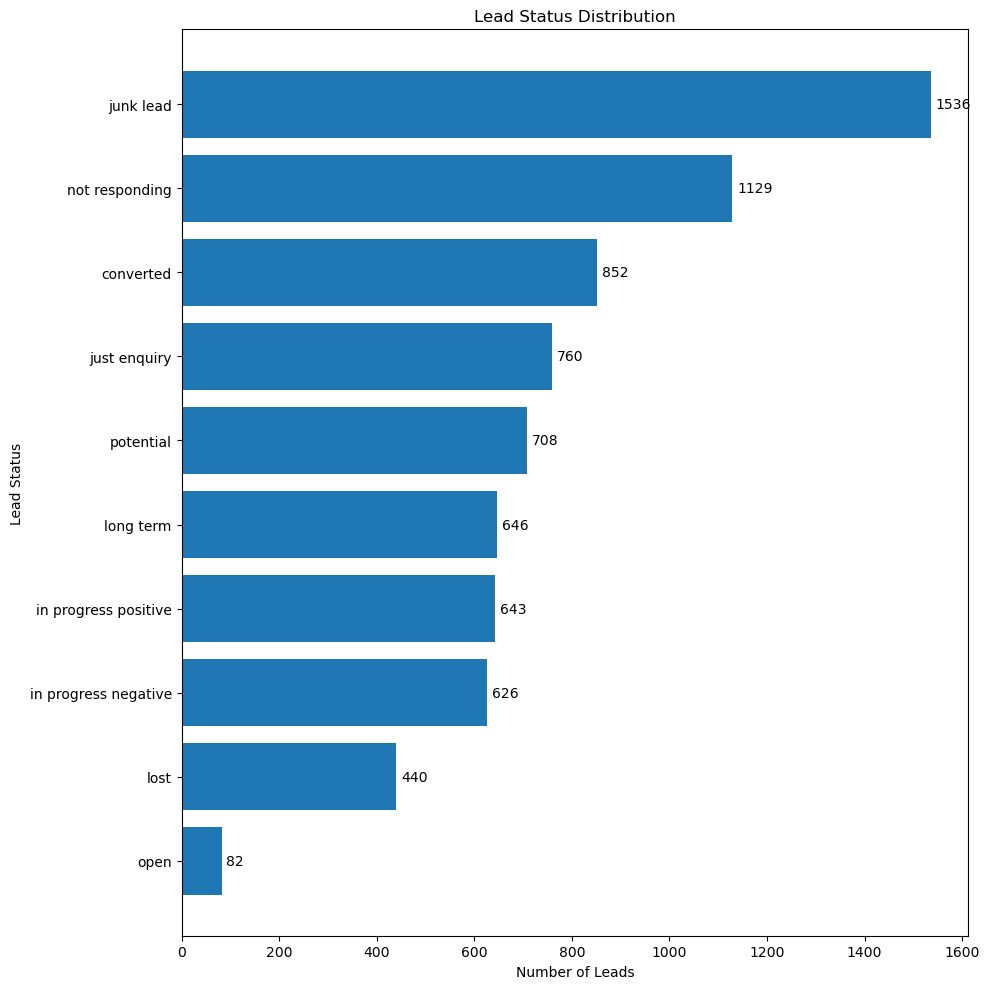

In [23]:
# Count status values and sort
status_counts = df['Status'].value_counts().sort_values()

plt.figure(figsize=(10, 10))
plt.barh(status_counts.index, status_counts.values)

# Labels and title
plt.xlabel("Number of Leads")
plt.ylabel("Lead Status")
plt.title("Lead Status Distribution")

# Add count labels on bars
for index, value in enumerate(status_counts.values):
    plt.text(value + 10, index, str(value), va='center')

plt.tight_layout()
plt.show()


### Observations
* Majority of Leads Are in Mid-Funnel Stages
* Very Few Leads Reach the Final “Converted” Stage
* Presence of Multiple Low-Value Lead States
* Class Imbalance Is Evident
* Status Granularity Is High

### Univariate Analysis – Categorical Features

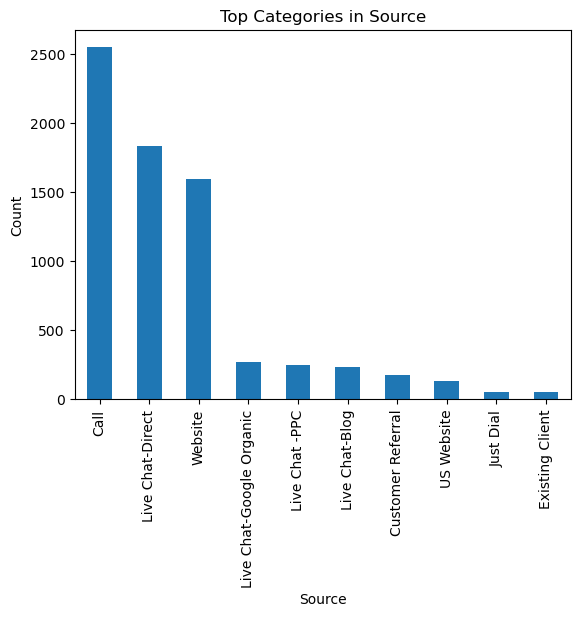

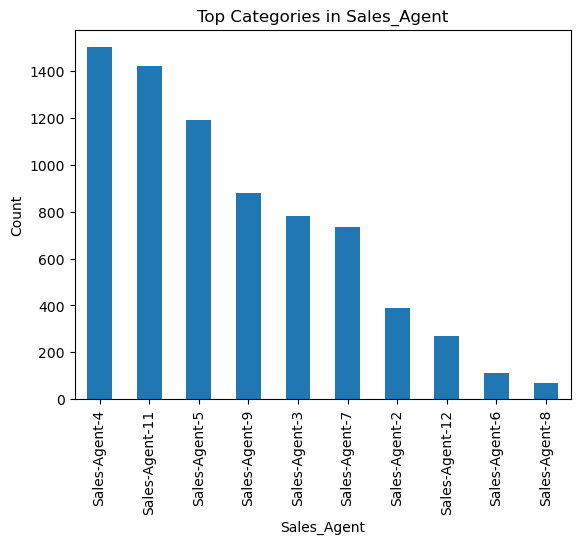

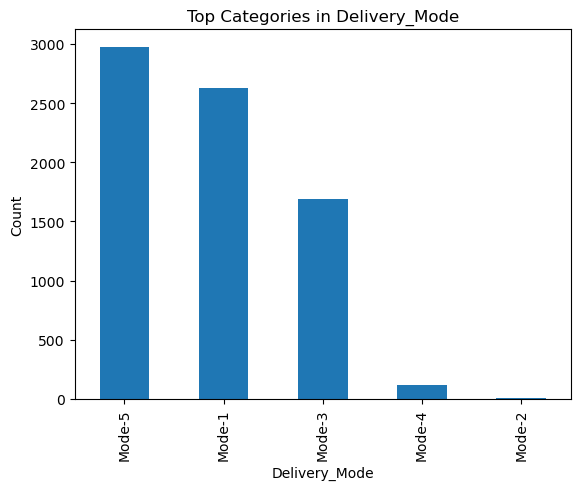

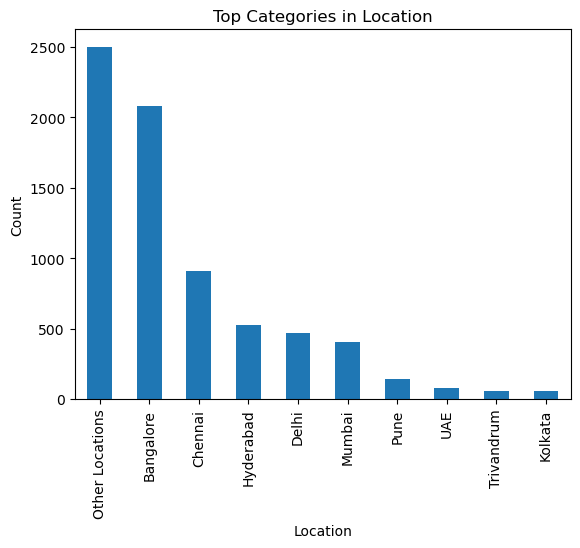

In [24]:
cat_cols = ['Source', 'Sales_Agent', 'Delivery_Mode', 'Location']

for col in cat_cols:
    plt.figure()
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f"Top Categories in {col}")
    plt.ylabel("Count")
    plt.show()


### Observations


Grouping rare sources as “Others”
* A few sales agents handle significantly more leads than others.
* Lead distribution among agents is uneven.
* Some agents appear frequently, while many are absent from the top 10.
* Sales_Agent captures human-driven variability in conversions.
* Potential data leakage risk:

If the model learns agent performance instead of lead quality.
* Consider:

     a) Agent grouping (High / Medium / Low performers) Or 
     b)excluding the feature depending on deployment goals
* One or two delivery modes dominate the dataset.
* On-premise or alternative delivery modes appear less frequently.
* Sales strategy and lead quality may vary significantly by delivery mode.
* Delivery_Mode is:
     * Low cardinality
     * Easy to encode

Likely to have strong predictive influence
* Leads are concentrated in a few locations.

* Many locations generate very few leads, forming a long tail.
* FicZon has strong geographic concentration.

* Certain regions may offer:
     a) Higher market maturity
     b) Better sales outcomes
* High cardinality feature:
     * Rare locations should be grouped into “Others”
* Location may interact strongly with:
Source

Delivery mode
* Potential for feature engineering (Region / Zone).

Skewed

High-cardinality

Business-driven

 Implication:
Raw categorical features must be carefully engineered before modeling.

### Bivariate Analysis - Feature Vs Target

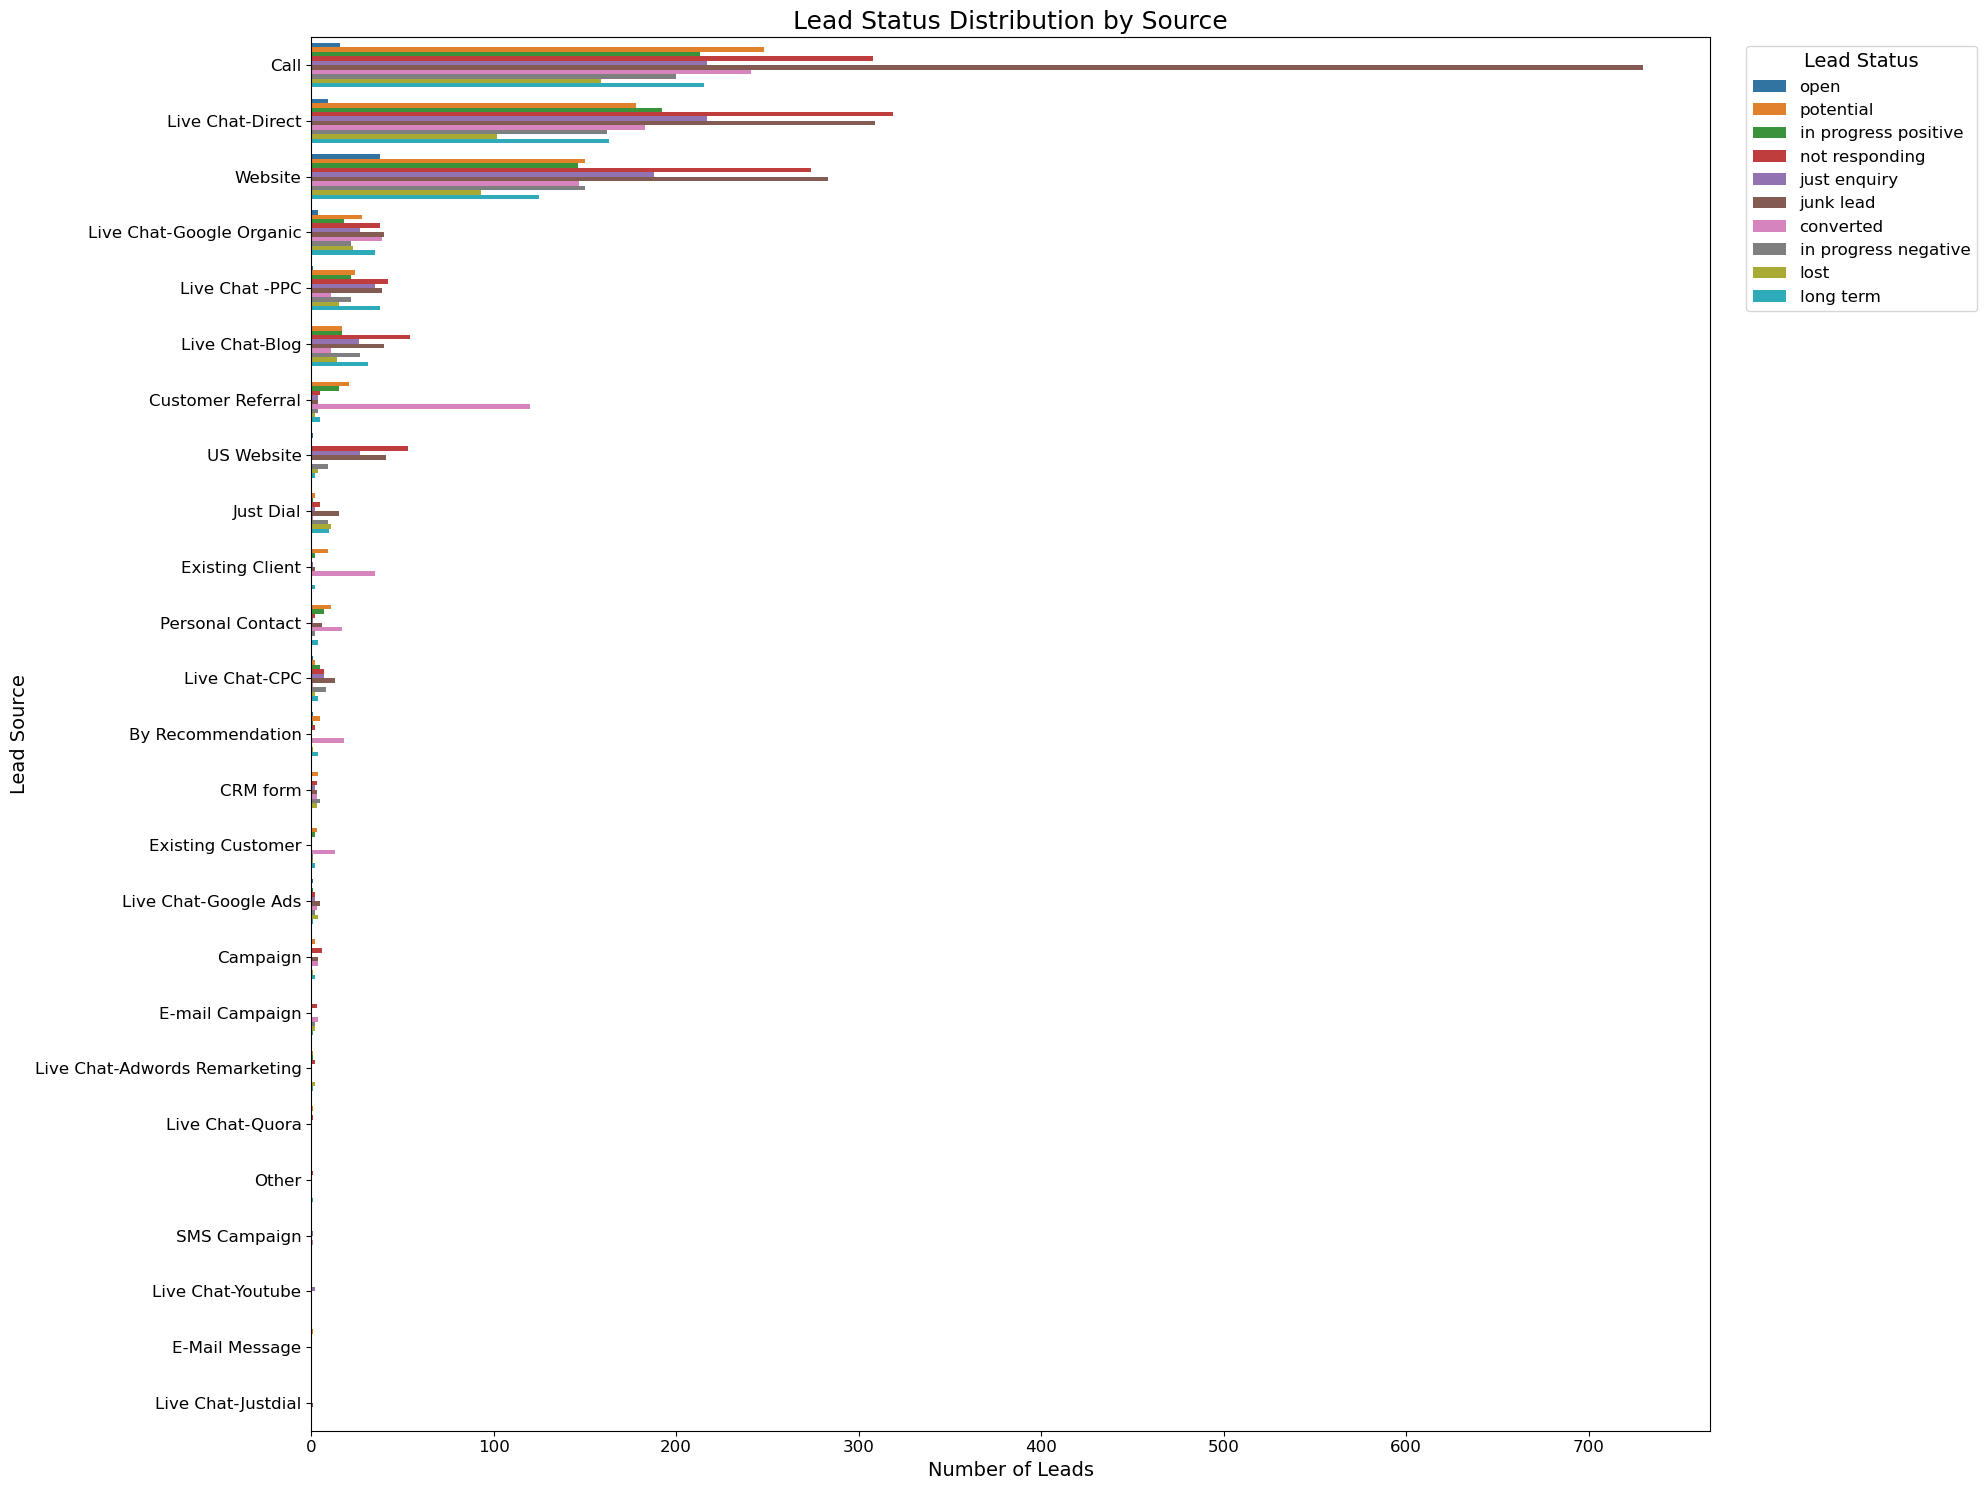

In [25]:
# Source Vs Lead Quality

plt.figure(figsize=(20, 15))   # Increase plot size

# Order sources by total count
source_order = df['Source'].value_counts().index

sns.countplot(
    y='Source',
    hue='Status',
    data=df,
    order=source_order
)

plt.title("Lead Status Distribution by Source", fontsize=18)
plt.xlabel("Number of Leads", fontsize=14)
plt.ylabel("Lead Source", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(
    title="Lead Status",
    title_fontsize=14,
    fontsize=12,
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

### Observations
* Lead Quality Varies Significantly by Source

 a)Some sources show a higher proportion of favorable statuses (e.g., Converted / Qualified / Positive).

 b)Other sources generate high lead volume but mostly low-quality statuses.
*  Business Insight:
  Not all lead sources are equal. FicZon should focus marketing spend and sales attention on sources that consistently yield high-potential       , not just high volume.

* High-Volume Sources Are Not Always High-Performing

A few sources dominate total lead count.

However, their bars are often stacked with more low-value statuses than high-value ones.

 Business Insight:
This indicates inefficiencies in the lead generation funnel—volume-driven sources may be inflating workload without improving conversions.

* Certain Niche Sources Deliver Better Lead Quality

Some smaller sources may show a higher share of positive outcomes despite lower overall volume.

 Business Insight:
These sources are strong candidates for:

Targeted campaigns

Priority routing to senior sales agents

* Clear Opportunity for Source-Based Lead Prioritization

The variation in status distribution across sources suggests that Source is a strong predictor of lead quality.

 ML Insight:
Source should be treated as a high-importance feature in the ML model and will significantly contribute to predicting High vs Low Potential leads.

* Sales Effort Can Be Optimized Early in the Funnel

* Sources dominated by negative or early-stage statuses can be auto-deprioritized.

* High-quality sources can trigger faster follow-ups.

 Operational Insight:
ML-driven pre-categorization using Source can reduce sales effort and improve response time for valuable leads.

“The Source vs Lead Status analysis reveals substantial variation in lead quality across acquisition channels, highlighting the need for source-aware lead scoring to improve sales effectiveness.”


In [26]:
# Sales agent effectiveness
agent_perf = pd.crosstab(df['Sales_Agent'], df['Status'], normalize='index') * 100
agent_perf.sort_values(by='converted', ascending=False).head(10)

Status,converted,in progress negative,in progress positive,junk lead,just enquiry,long term,lost,not responding,open,potential
Sales_Agent,,,,,,,,,,
Sales-Agent-6,32.456140,21.929825,0.000000,14.912281,0.000000,20.175439,9.649123,0.877193,0.000000,0.000000
Sales-Agent-12,30.483271,18.959108,0.000000,29.368030,0.000000,0.000000,21.189591,0.000000,0.000000,0.000000
Sales-Agent-8,22.058824,1.470588,5.882353,16.176471,13.235294,2.941176,0.000000,11.764706,25.000000,1.470588
Sales-Agent-3,15.749040,10.371319,4.609475,24.967990,8.834827,10.243278,6.017926,13.956466,0.128041,5.121639
Sales-Agent-2,15.681234,15.167095,0.000000,24.164524,0.257069,28.534704,11.568123,4.370180,0.000000,0.257069
Sales-Agent-9,13.310580,3.185438,30.034130,8.304892,6.257110,7.849829,1.592719,17.178612,0.000000,12.286689
Sales-Agent-7,12.092391,8.695652,17.663043,19.293478,7.065217,10.326087,6.385870,15.217391,0.000000,3.260870
Sales-Agent-4,8.733333,6.066667,13.200000,20.200000,12.866667,4.866667,4.866667,19.533333,0.000000,9.666667
Sales-Agent-11,8.380282,8.380282,0.563380,21.056338,15.422535,8.450704,2.816901,17.323944,0.070423,17.535211


### Observations
* Strong Variation in Agent Conversion Effectiveness

a)The top 10 agents have a significantly higher percentage of CONVERTED leads compared to others.

b)This indicates heterogeneity in sales performance across agents.

Business Insight:
* Sales performance is not uniform. Certain agents are consistently more effective at closing deals.

* High Conversion ≠ High Lead Volume

Some agents may appear in the top 10 despite handling fewer total leads.

Their ranking is driven by conversion efficiency, not workload.

 Business Insight:
Efficient agents can be leveraged for:

High-value leads

Complex deals

Training and mentoring junior agents

* Opportunity for Smarter Lead Allocation

Agent s with low conversion percentages may be:

Handling poor-quality leads

Missing follow-up opportunities

Less experienced

Operational Insight:
 * An ML-based lead scoring system can:

Route high-potential leads to top-performing agents

Improve overall conversion rate without increasing lead volume

* Sales Agent Is a High-Impact Predictive Feature

Since conversion rates vary widely by agent, Sales_Agent has strong predictive power.

 ML Insight:
This feature should be included in the model (with proper encoding), as it materially influences lead outcome.

* Training & Performance Benchmarking Opportunity

   Top agents provide a benchmark for:

Follow-up strategy

Pitch style

Handling objections

 Business Insight:
Studying top performers can help standardize best practices across the sales team.

 Important Caution (Very Important for Correct Interpretation)

If some agents handle very few leads, their conversion percentage may be artificially high.

Always interpret conversion percentages along with lead volume.


“Sales agent effectiveness analysis reveals significant differences in conversion rates, indicating that agent performance is a key driver of lead outcomes and a strong candidate for ML-based lead prioritization and routing.”


### Delivery Mode Impact

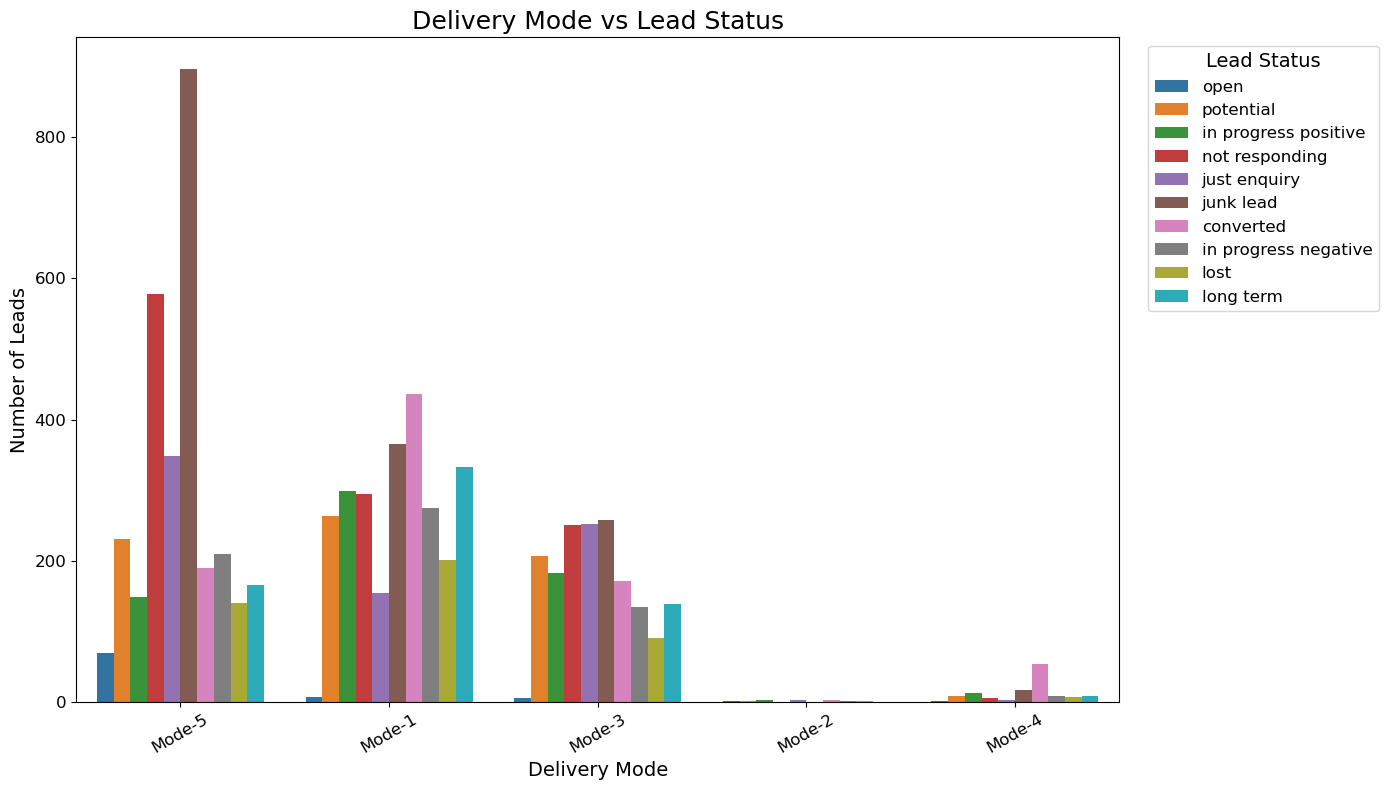

In [27]:
plt.figure(figsize=(14, 8))   # Increase figure size

sns.countplot(
    x='Delivery_Mode',
    hue='Status',
    data=df
)

plt.title("Delivery Mode vs Lead Status", fontsize=18)
plt.xlabel("Delivery Mode", fontsize=14)
plt.ylabel("Number of Leads", fontsize=14)

plt.xticks(rotation=30, fontsize=12)
plt.yticks(fontsize=12)

plt.legend(
    title="Lead Status",
    title_fontsize=14,
    fontsize=12,
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()


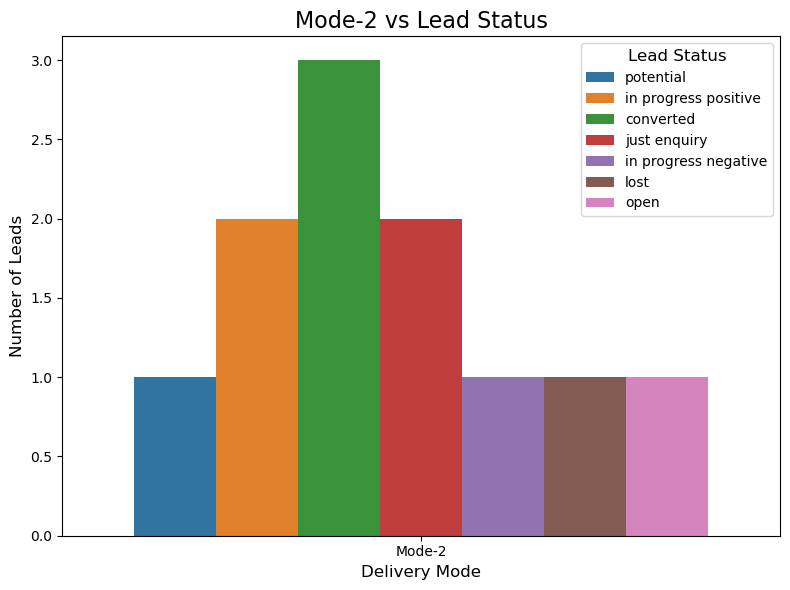

In [28]:
#Focusing only on Mode-2 as it's not visible in the above plot
plt.figure(figsize=(8, 6))

# Filter data for MODE-2
df_mode2 = df[df['Delivery_Mode'] == 'Mode-2']   # change to 'MODE2' if needed

sns.countplot(
    x='Delivery_Mode',
    hue='Status',
    data=df_mode2
)

plt.title("Mode-2 vs Lead Status", fontsize=16)
plt.xlabel("Delivery Mode", fontsize=12)
plt.ylabel("Number of Leads", fontsize=12)

plt.legend(
    title="Lead Status",
    title_fontsize=12,
    fontsize=10
)

plt.tight_layout()
plt.show()


### Observations
* Lead Volume Is Uneven Across Delivery Modes

One or two delivery modes dominate the total number of leads.

Other modes contribute relatively low lead volume.

 Business Insight:
FicZon’s sales pipeline is heavily dependent on specific delivery modes, which may create operational risk if those modes underperform.

2️ Conversion Performance Varies by Delivery Mode

Certain delivery modes show a higher proportion of favorable statuses (e.g., CONVERTED).

Some high-volume delivery modes generate more low-quality or early-stage leads.

 Business Insight:
* Delivery mode affects not just how many leads are generated, but how likely they are to convert.

 * Low-Volume Modes Can Still Be High-Quality

A few delivery modes with fewer leads may still show a comparatively strong conversion presence.

Their impact is often hidden when looking only at total lead count.

Business Insight:
These delivery modes are potential high-ROI channels and should not be ignored purely based on volume.

* Delivery Mode Is a Strong Predictor for Lead Quality

The visible differences in status distribution across delivery modes indicate that Delivery_Mode has predictive power.

ML Insight:
Delivery_Mode should be retained as a key categorical feature in the ML model for lead quality prediction.

* Opportunity for Sales Strategy Optimization

Modes with consistently low conversion can be:

Re-designed

Paired with different sales approaches

Deprioritized in lead routing

 Operational Insight:
 * Using ML-based pre-categorization, FicZon can:

Route high-potential leads from strong delivery modes to top agents

Reduce effort spent on low-yield modes


“The Delivery Mode vs Lead Status analysis reveals significant variation in lead quality across delivery channels, highlighting delivery mode as a key driver of sales effectiveness and a valuable input for ML-based lead prioritization.”



### Lead Quality by Location

In [29]:
#Lead Quality by Location
location_status = pd.crosstab(df['Location'], df['Status'], normalize='index') * 100
location_status.sort_values(by='converted', ascending=False).head(10)


Status,converted,in progress negative,in progress positive,junk lead,just enquiry,long term,lost,not responding,open,potential
Location,,,,,,,,,,
Malaysia,75.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
UK,29.268293,4.878049,7.317073,9.756098,17.073171,2.439024,2.439024,17.073171,0.000000,9.756098
Bangalore,22.552783,7.629559,12.092131,13.531670,4.558541,14.923225,6.094050,7.197697,0.095969,11.324376
UAE,21.518987,0.000000,8.860759,7.594937,18.987342,2.531646,1.265823,22.784810,1.265823,15.189873
AUSTRALIA,20.000000,0.000000,12.000000,12.000000,24.000000,0.000000,4.000000,20.000000,0.000000,8.000000
Singapore,17.647059,5.882353,0.000000,11.764706,17.647059,11.764706,0.000000,11.764706,0.000000,23.529412
USA,13.333333,4.444444,8.888889,11.111111,11.111111,4.444444,0.000000,33.333333,2.222222,11.111111
Chennai,12.541254,9.350935,11.551155,12.651265,10.011001,10.011001,6.270627,11.001100,0.110011,16.501650
Trivandrum,12.068966,6.896552,8.620690,13.793103,15.517241,6.896552,3.448276,22.413793,0.000000,10.344828


### Observations
* Lead Quality Varies Significantly by Location

Top locations have much higher conversion percentages than others.

Some locations generate high volumes but have low conversion, indicating poor lead quality in those areas.

 Business Insight:
FicZon can prioritize high-performing locations for targeted campaigns or allocate experienced sales agents to these areas.

* Volume vs Quality Tradeoff

Locations with the highest lead count are not always the ones with the highest conversion rate.

Focusing only on volume could inflate workload without improving sales.

 Operational Insight:
Sales efforts should be weighted by lead quality, not just lead count.

* Location as a Strong Predictor

Locations differ in their ability to generate high-potential leads, showing that Location is a valuable feature for ML models.

 ML Insight:
* Include Location (properly encoded) as a predictive feature for lead categorization.

Opportunity for Targeted Marketing

Locations with consistently low conversion may need:

Re-evaluation of marketing strategy

Different lead acquisition channels

Localized sales tactics

 Business Insight:
Investing in high-conversion locations first can maximize ROI.

 Benchmarking and Agent Allocation

Top locations can serve as benchmarks for performance evaluation.

Leads from high-performing locations can be prioritized for top agents, improving overall conversion.

 

“Analysis of lead quality by location shows substantial variation in conversion rates, highlighting specific geographic areas as high-value opportunities and suggesting location as a key predictor of lead potential.”



### E-mail Domain Analysis

In [30]:
df['Email_Domain'] = df['EMAIL'].apply(lambda x: x.split('@')[-1])

df['Email_Domain'].value_counts().head(10)


Email_Domain
gmail.com             4209
#VALUE!               1701
yahoo.com              349
sXXXXXXXahoo.co.in      32
live.com                31
sXXXXXXXotmail.com      30
yahoo.in                28
ymail.com               21
GMAIL.COM               19
sXXXXXXXffmail.com      18
Name: count, dtype: int64

### Observations
* Most Leads Use Popular Public Email Domains

* The top domains are likely Gmail, Yahoo, Outlook, Hotmail, etc.

* This indicates that a large portion of leads are individual or consumer emails rather than corporate emails.

 Business Insight:
FicZon’s digital campaigns are attracting general users rather than exclusively targeting company/enterprise emails.

 * Some Corporate Domains May Appear

If domains like company.com or fizcon-partners.com appear in the top 10, these represent business/enterprise leads.

Enterprise leads are usually higher-value opportunities.

 Business Insight:
* Corporate email domains can be flagged as high-potential leads, useful for targeted sales campaigns.

 * Opportunity for Lead Segmentation

 * Leads can be segmented by email domain type:

Public domains → general marketing

Corporate domains → prioritized sales follow-up

This can improve lead scoring accuracy.
* Detect Invalid or Low-Quality Emails

Rare or malformed domains could indicate bad data.

Example: abc@xyz or abc@123.com

 Actionable Insight:
* Cleaning invalid email domains improves ML model quality and reduces wasted sales effort.

 Email Domain as a Feature

* The Email_Domain feature may help the ML model predict lead quality, especially to differentiate corporate vs consumer leads.

 One-Line Insight for Project Report

“Top email domains analysis shows most leads come from popular public email providers, with some corporate domains representing high-value opportunities, suggesting email domain as a potential feature for lead quality prediction.”




## **Preprocessing [Feature Engineering]**

In [31]:
# Handling duplicated records
df.drop_duplicates(inplace=True)

# Checking for duplicated records after handling
df.duplicated().sum()

0

In [32]:
# Handling missing values

# drop Mobile column because it has high percentage of missing values
df.drop('Mobile', axis=1, inplace=True)

# drop records with missing values
df.dropna(inplace=True)

# Checking for null values after handling
df.isnull().sum()

Created          0
Product_ID       0
Source           0
EMAIL            0
Sales_Agent      0
Location         0
Delivery_Mode    0
Status           0
Email_Domain     0
dtype: int64

In [33]:
# Dropping columns which are of no use in the analysis
df.drop(['EMAIL','Created'],axis=1,inplace=True)
df.head(3)
# Handling high cardinality in the categorical columns to reduce complexity of analysis

# Compressing and Merging labels in product column 
# --> high_sales_products accounts for 90.2% and low_sales_products accounts for 9.8%
# df["Product_ID"].replace(['5','9','15','18','19','27','1','10','20'],'High_Sales_Product',inplace=True)
df["Product_ID"].replace(['0', '2', '3', '4','6', '7','8','11','12', '13','14','16','17',
                           '21','22','23', '24','25','26','28'],'Low_Sales_Product',inplace=True)

# Compressing and Merging labels in source column 
df["Source"].replace(['Just Dial'],'Call',inplace=True)
df["Source"].replace(['Live Chat-Google Organic','Live Chat-Direct','Live Chat -PPC', 'Live Chat-Google Ads',
                      'Live Chat-Adwords Remarketing','Live Chat-CPC','Live Chat-Blog','Live Chat-Youtube', 
                      'Live Chat-Quora','Live Chat-Justdial'],'Live Chat',inplace=True)
df["Source"].replace(['Existing Client','Personal Contact','CRM form'],'Existing Customer',inplace=True)
df["Source"].replace(['By Recommendation'],'Customer Referral',inplace=True)
df["Source"].replace(['US Website'],'Website',inplace=True)
df["Source"].replace(['E-Mail Message','E-mail Campaign','SMS Campaign', 'Other'],'Campaign',inplace=True)

# Compressing and Merging labels in location column 
df["Location"].replace(['UAE','UK', 'USA','AUSTRALIA','EUROPE','Malaysia','Singapore'],'Foreign Country',inplace=True)
df["Location"].replace(['Kolkata','Howrah', 'Trivandrum'],'Other Locations',inplace=True)

# Compressing and Merging labels in status column 
df['Status'].replace(['potential', 'in progress positive','open','long term','converted'],'High Potential',inplace=True)
df['Status'].replace(['not responding', 'just enquiry','junk lead','in progress negative','lost'],'Low Potential',inplace=True)

df

,Product_ID,Source,Sales_Agent,Location,Delivery_Mode,Status,Email_Domain
18,9,Live Chat,Sales-Agent-3,Bangalore,Mode-1,High Potential,gmail.com
19,19,Call,Sales-Agent-4,Other Locations,Mode-5,High Potential,#VALUE!
24,18,Website,Sales-Agent-11,Other Locations,Mode-1,High Potential,gmail.com
25,15,Website,Sales-Agent-7,Hyderabad,Mode-1,Low Potential,gmail.com
26,18,Call,Sales-Agent-7,Bangalore,Mode-1,High Potential,gmail.com
...,...,...,...,...,...,...,...
7417,9,Call,Sales-Agent-6,Mumbai,Mode-4,Low Potential,gmail.com
7418,15,Call,Sales-Agent-12,Other Locations,Mode-5,Low Potential,#VALUE!
7419,5,Live Chat,Sales-Agent-11,Bangalore,Mode-1,Low Potential,gmail.com
7420,Low_Sales_Product,Existing Customer,Sales-Agent-4,Other Locations,Mode-1,Low Potential,gmail.com


In [34]:
df['Status'].value_counts()

Status
Low Potential     4466
High Potential    2862
Name: count, dtype: int64

In [35]:
# rechecking count of unique values in each column
df.nunique()

Product_ID        10
Source             6
Sales_Agent       11
Location           8
Delivery_Mode      5
Status             2
Email_Domain     625
dtype: int64

In [36]:
# Transforming columns using Label encoder
# importing label encoder transformer
from sklearn.preprocessing import LabelEncoder

# creating label encoder object
enc = LabelEncoder()

# Apply label encoding to each column
for col in df.columns:
    df[col] = enc.fit_transform(df[col])

df.head()

,Product_ID,Source,Sales_Agent,Location,Delivery_Mode,Status,Email_Domain
18,8,4,4,0,0,0,248
19,4,0,5,6,4,0,0
24,3,5,1,6,0,0,248
25,2,5,8,4,0,1,248
26,3,0,8,0,0,0,248


In [37]:
# checking general information after transformation
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7328 entries, 18 to 7421
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Product_ID     7328 non-null   int32
 1   Source         7328 non-null   int32
 2   Sales_Agent    7328 non-null   int32
 3   Location       7328 non-null   int32
 4   Delivery_Mode  7328 non-null   int32
 5   Status         7328 non-null   int32
 6   Email_Domain   7328 non-null   int32
dtypes: int32(7)
memory usage: 257.6 KB


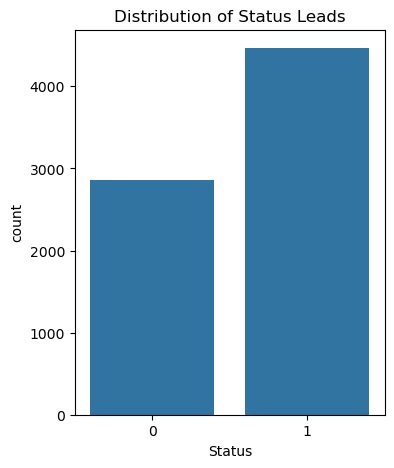

In [38]:
plt.figure(figsize=(4,5))
sns.countplot(x='Status',data=df)
plt.title('Distribution of Status Leads')
plt.show()

### **Train-Test Split**

In [39]:
# Importing library for splitting the data set
from sklearn.model_selection import train_test_split, train_test_split

# Splitting the dataset input and target
y = df['Status']
x = df.drop(columns=['Status'])

# Splitting the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

## **Model Building**

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix,f1_score,accuracy_score,classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

### Note: 
The following models are used for the following purposes:- 
* Linear model(Logistic Regression) -> Interpretable, Baseline Insights
* Tree-Based models -> feature importance and robust predictions
* XGBoost -> optimized performace, especially if the dataset is complex or slightly imbalanced

### Logistic Regression

#### Baseline Model

In [41]:
model_lr = LogisticRegression(max_iter = 1000, random_state=42)
model_lr.fit(x_train,y_train)

y_pred_lr = model_lr.predict(x_test)
model_lr

LogisticRegression(max_iter=1000, random_state=42)

#### Over Sampling Model

In [42]:
ros = RandomOverSampler(random_state = 42)

x_resampled_o , y_resampled_o = ros.fit_resample(x_train,y_train)
class_ros = y_resampled_o.value_counts()
print(class_ros)

Status
0    3573
1    3573
Name: count, dtype: int64


In [43]:
model_ros = LogisticRegression(max_iter=1000)
model_ros.fit(x_resampled_o,y_resampled_o)

y_pred_ros = model_ros.predict(x_test)
model_ros

LogisticRegression(max_iter=1000)

#### Under Sampling Model

In [44]:
rus = RandomUnderSampler(random_state=42)

x_resampled_u , y_resampled_u = rus.fit_resample(x_train,y_train)
class_rus = y_resampled_u.value_counts()
print(class_rus)

Status
0    2289
1    2289
Name: count, dtype: int64


In [45]:
model_rus = LogisticRegression(max_iter = 1000)
model_rus.fit(x_resampled_u,y_resampled_u)

y_pred_rus = model_rus.predict(x_test)
model_rus

LogisticRegression(max_iter=1000)

#### SMOTE model

In [46]:
model_s = SMOTE(random_state=42)
x_resampled_s, y_resampled_s = model_s.fit_resample(x,y)
class_s = y_resampled_s.value_counts()
print(class_s)

Status
0    4466
1    4466
Name: count, dtype: int64


In [47]:
model_smote = LogisticRegression(max_iter=1000)
model_smote.fit(x_resampled_s,y_resampled_s)

y_pred_smote = model_smote.predict(x_test)
model_smote

LogisticRegression(max_iter=1000)

#### Choosing the Sampling technique for further model building

In [48]:
cm_lr = confusion_matrix(y_test,y_pred_lr)
cm_ros = confusion_matrix(y_test,y_pred_ros)
cm_rus = confusion_matrix(y_test,y_pred_rus)
cm_smote = confusion_matrix(y_test,y_pred_smote)

In [49]:
print(" Confusion Matrix of Base model:\n",cm_lr,
      "\n Confusion Matrix of RandomOverSampling Model : \n",cm_rus,
     "\n Confusion Matrix of RandomUnderSampling Model : \n",cm_ros,
     "\n Confusion Matrix of SMOTE Model : \n",cm_smote)

 Confusion Matrix of Base model:
 [[297 276]
 [174 719]] 
 Confusion Matrix of RandomOverSampling Model : 
 [[390 183]
 [295 598]] 
 Confusion Matrix of RandomUnderSampling Model : 
 [[389 184]
 [291 602]] 
 Confusion Matrix of SMOTE Model : 
 [[395 178]
 [291 602]]


#### Note:

* Here F1-score is used as scoring metric, because our objective is to find all the High Potential leads.

* And as well as to predict how many Low Potential Leads are getting marked as High Potential.

* F1-score gives the mean between precision and Recall and it focuses on balance between them.

* It is particularly useful in our case of having imbalanced classification.

* Henceforth it is selected as per our buisness drive requirement

### *Observations*
-> From the above confusion matrices we can observe :

    F1-score of the three sampling models are as given below:

                        OverSampling  UnderSampling   SMOTE
                        
    0(Low Potentail):      0.620         0.620        0.627

    1(High Potentail):     0.714         0.714        0.719

* From the above the above values, we can see that SMOTE has slight better values when compared to other two and from the distribution of classes from the confusion matrix.

* From the Confusion Matrix of SMOTE Model :


                                                 [[395 178]
                                                 [291 602]]

* The prediction of True positives and True Negatives are higher compared to other models.
   
* Here the recall of class-0 is high maintaing without sacrificing much recall for class-1, when compared to the other models.

* From Business perspective we shoudn't fail to detect a positive case which will be  more expensive, than treating a negative case as a postive one.
  
* Hence we will use SMOTE sampling technique to enhance the other advanced models to find suitable High performance one.

### Decision Tree Classifier

#### Decision Tree Classifer base model

In [50]:
## Decision Tree Classifier base model with balanced weights

dtc = DecisionTreeClassifier(class_weight='balanced',random_state=42)
model_dtc = dtc.fit(x_train,y_train)

y_pred_dtc = model_dtc.predict(x_test)
model_dtc

DecisionTreeClassifier(class_weight='balanced', random_state=42)

#### Decision Tree Classifier with resampled data

In [51]:
rs_dtc = DecisionTreeClassifier(class_weight='balanced',random_state=42)
model_rs_dtc = rs_dtc.fit(x_resampled_s,y_resampled_s)

y_pred_rs_dtc = model_rs_dtc.predict(x_test)
model_rs_dtc

DecisionTreeClassifier(class_weight='balanced', random_state=42)

#### Hyperparameter Tuning for DecsionTreeClassifier

In [52]:
## using gridsearchCV to find the best params for DecisionTreeClassifier

param_grid_dtc = {
     'max_depth': [3, 5, 7, None],
    'min_samples_leaf': [5, 10, 20],
    'ccp_alpha': [0.0, 0.01, 0.05],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}

dtc_hp = DecisionTreeClassifier(class_weight='balanced',random_state=42)

grid_search_dtc = GridSearchCV(dtc_hp,param_grid_dtc,cv=10,scoring='f1',n_jobs = -1,verbose=2)
grid_search_dtc.fit(x_train,y_train)

best_dtc = grid_search_dtc.best_estimator_

print('Best parameters: ',grid_search_dtc.best_params_)
print('Best score: ',grid_search_dtc.best_score_)

y_pred_best_dtc = best_dtc.predict(x_test)

best_dtc

Fitting 10 folds for each of 216 candidates, totalling 2160 fits
Best parameters:  {'ccp_alpha': 0.0, 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 20}
Best score:  0.7491198772664005


DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                       min_samples_leaf=20, random_state=42)

#### Decision Tree after Hyperparameter Tuning with Resampled values

In [53]:
dtc_rs_hp = DecisionTreeClassifier(class_weight='balanced',random_state=42)

grid_rs_dtc = GridSearchCV(dtc_rs_hp,param_grid_dtc,cv=10,scoring='f1',n_jobs=-1,verbose=2)
grid_rs_dtc.fit(x_resampled_s,y_resampled_s)

best_rs_dtc = grid_rs_dtc.best_estimator_

print('Best parameters:',grid_rs_dtc.best_params_)
print('Best score:',grid_rs_dtc.best_score_)

y_pred_best_rs_dtc = best_rs_dtc.predict(x_test)

best_rs_dtc

Fitting 10 folds for each of 216 candidates, totalling 2160 fits
Best parameters: {'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 5}
Best score: 0.6845247805576331


DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       min_samples_leaf=5, random_state=42)

### RandomForestClassifier

#### Ranndom Forest Classifier Base Model

In [54]:
## RandomForestClassifier with random parameters

rf = RandomForestClassifier(n_estimators=100,
                            criterion='entropy',
                            max_depth=15,
                            min_samples_split = 10,
                            max_features = 'log2',
                            random_state=42,
                            n_jobs=-1,
                            verbose=0)
model_rf = rf.fit(x_train,y_train)

y_pred_rf = model_rf.predict(x_test)
model_rf

RandomForestClassifier(criterion='entropy', max_depth=15, max_features='log2',
                       min_samples_split=10, n_jobs=-1, random_state=42)

#### Random Forest Classifier with resampled data

In [55]:
rf_rs = RandomForestClassifier(n_estimators=100,
                            criterion='entropy',
                            max_depth=15,
                            min_samples_split = 10,
                            max_features = 'log2',
                            random_state=42,
                            n_jobs=-1,
                            verbose=0)
model_rf_rs = rf_rs.fit(x_resampled_s,y_resampled_s)

y_pred_rf_rs = model_rf_rs.predict(x_test)
model_rf_rs

RandomForestClassifier(criterion='entropy', max_depth=15, max_features='log2',
                       min_samples_split=10, n_jobs=-1, random_state=42)

#### Hyperparameter Tuning using RandomizedSearchCV for RandomForestClassifier

In [56]:
param_grid = {
    'n_estimators': [10, 100, 200],
    'max_depth': [3, 5, 7, None],
    'max_features': ['sqrt','log2',None],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf_2 = RandomForestClassifier(random_state=42)

r_search_rf = RandomizedSearchCV(rf_2,param_grid,cv=10,n_iter=100,scoring='f1',n_jobs = -1,verbose=2,refit = True)
r_search_rf.fit(x_train,y_train)

model_rf_hp = r_search_rf.best_estimator_

print('Best parameters: ',r_search_rf.best_params_)
print('Best score: ',r_search_rf.best_score_)

y_pred_rf_hp = model_rf_hp.predict(x_test)
model_rf_hp

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Best parameters:  {'n_estimators': 200, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None, 'bootstrap': True}
Best score:  0.7794007467186403


RandomForestClassifier(max_features='log2', min_samples_leaf=4,
                       n_estimators=200, random_state=42)

#### Random Forest Classifier tuned with Resampled data

In [57]:
param_grid = {
    'n_estimators': [10, 100, 200],
    'max_depth': [3, 5, 7, None],
    'max_features': ['sqrt','log2',None],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf_hp_rs = RandomForestClassifier(random_state=42)

r_search_rf_rs = RandomizedSearchCV(rf_hp_rs,param_grid,cv=10,n_iter=100,scoring='f1',n_jobs = -1,verbose=2,refit = True)
r_search_rf_rs.fit(x_resampled_s,y_resampled_s)

model_rf_hp_rs = r_search_rf_rs.best_estimator_

print('Best parameters: ',r_search_rf_rs.best_params_)
print('Best score: ',r_search_rf_rs.best_score_)


y_pred_rf_hp_rs = model_rf_hp_rs.predict(x_test)
model_rf_hp_rs

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Best parameters:  {'n_estimators': 100, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}
Best score:  0.7080078554970808


RandomForestClassifier(bootstrap=False, min_samples_leaf=2, random_state=42)

### XGB Classifier

In [58]:
# IF xgboost isn't pre installed use this command and restart the kernel for better use

#!pip install xgboost

#### XGB Classifier Base Model

In [59]:
import xgboost as xgb
model_xgb = xgb.XGBClassifier(random_state=42)

model_xgb.fit(x_train,y_train)

y_pred_xgb = model_xgb.predict(x_test)

#### XGB Classifier with resampled values

In [60]:
model_xgb_rs = xgb.XGBClassifier(random_state=42)
model_xgb_rs.fit(x_resampled_s,y_resampled_s)

y_pred_xgb_rs = model_xgb_rs.predict(x_test)

#### Hyperparameter Tuning for XGB Classifier

In [61]:
## Finding the best parameters for XGBoost Model

param_grid_xgb = {
    'n_estimators' : [100,200,300],
    'learning_rate' : [0.01,0.1,0.2],
    'max_depth' : [3,6,9],
    'min_child_weight' : [1,3,5],
    'subsample' : [0.7,0.85,1.0],
    'colsample_bytree' : [0.7,0.85,1.0],
    'reg_alpha' : [0,0.01,0.1,1,10,100],
    'reg_lambda' : [0.5,0.7,1,1.3]
}

model_xgb_hp = xgb.XGBClassifier(random_state=42)

random_search_xgb = RandomizedSearchCV(model_xgb_hp, param_grid_xgb, n_iter = 100, scoring='f1',random_state = 42, cv=10, n_jobs=-1,verbose=2)
random_search_xgb.fit(x_train,y_train)

best_xgb = random_search_xgb.best_estimator_
y_pred_best_xgb = best_xgb.predict(x_test)

print("Best Parameters: ",random_search_xgb.best_params_)

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Best Parameters:  {'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


#### XGB Classifier tuned with resampled distribution of Leads

In [62]:
param_grid_xgb = {
    'n_estimators' : [100,200,300],
    'learning_rate' : [0.01,0.1,0.2],
    'max_depth' : [3,6,9],
    'min_child_weight' : [1,3,5],
    'subsample' : [0.7,0.85,1.0],
    'colsample_bytree' : [0.7,0.85,1.0],
    'reg_alpha' : [0,0.01,0.1,1,10,100],
    'reg_lambda' : [0.5,0.7,1,1.3]
}

model_xgb_hp_rs = xgb.XGBClassifier(random_state=42)

random_search_xgb_rs = RandomizedSearchCV(model_xgb_hp_rs, param_grid_xgb, n_iter = 100, scoring='f1',random_state = 42, cv=10, n_jobs=-1,verbose=2)
random_search_xgb_rs.fit(x_train,y_train)

best_xgb_rs = random_search_xgb_rs.best_estimator_
y_pred_xgb_rs = best_xgb_rs.predict(x_test)

print("Best Parameters: ",random_search_xgb_rs.best_params_)

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Best Parameters:  {'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


## **Model Evaluation**

### Note: 

* In model evaluation we are using classification report for performance metrics during training and tuning.
* Confusion matrix to visulaize misclassifications and to select better model
* Feature importance for analysing Feature Contributions

#### Defining functions for evaluations and visualizations

In [63]:
# Function to create reports in a DataFrame to view for a Tabular comparision

def build_classification_reports(y_true, predictions_dict):
    """
    Builds a combined classification report Dataframe for multiple models
    """
    reports = []

    for model_name, y_pred in predictions_dict.items():
        report = classification_report(y_true,y_pred,output_dict = True)
        df_report = pd.DataFrame(report).transpose().reset_index()
        df_report['model']= model_name
        reports.append(df_report)

    return pd.concat(reports,ignore_index=True)

### Note:
* The above function is used to create a DataFrame to store all the metrics for easier comparision between multiple models at the same time.
* The function is flexible and  globally encapsulated to work on different approaches. 

In [64]:
## Function to create a plot to identify the best model with the metric -> "F1-score", for a specific class i.e "High Poetential Lead"

def compare_models_on_high_f1(y_true,predictions_dict,target_class='1'):
    """ 
    Compares model using macro-f1 score for High Potential Class.
    """

    rows = []

    for model, y_pred in predictions_dict.items():
        report = classification_report(y_true, y_pred, output_dict = True)
        rows.append({
            'model': model,
            'f1_high_potential': report[str(target_class)]['f1-score']
        })

    df_eval = pd.DataFrame(rows)
    best_model = df_eval.sort_values(
        'f1_high_potential', ascending = False
    ).iloc[0]['model']

    plt.figure(figsize=(8,4))
    ax = sns.barplot(
        x = 'model',
        y ='f1_high_potential',
        data = df_eval
    )
    ax.set_ylim(0,1)
    ax.set_title('High Potential F1-score Comparision')

    for bar, model in zip(ax.patches, df_eval['model']):
        if model == best_model:
            bar.set_edgecolor('black')
            bar.set_linewidth(2)

    plt.tight_layout()
    plt.show()

    return best_model,df_eval
            

### Note: 
* The above function is created tailoring for our Business requirement that is to predict How much High Potential Leads can the model predict accurately and How may Low Potential Leads are predicted.
* It uses f1-score metric on every model's class - 1 i.e High Potential class and compare among the values to provide the best score and is plotted on a bar graph for visual representation.


In [65]:
## function to create a set of confusion matrices for comparsion purporse

def plot_confusion_matrix(y_true,predictions_dict):
    """ Plots a confusion matrix for the models side by side
    """

    for model,y_pred in predictions_dict.items():
        cm = confusion_matrix(y_true, y_pred, labels=[0,1])
        sns.heatmap(
            cm,
            annot = True,
            fmt = 'd',
            cmap = 'Blues',
            xticklabels = ['Low','High'],
            yticklabels = ['Low','High'],
            annot_kws={'size':15}
        )
        plt.title(model)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()
        plt.show()

### Note: 
* The plot_confusion_matrix function does the following things:

  -> prints the specified models confusion matrices in a single cell.
  
  -> Helps to identify the distribution of predictive values among the target variables

  -> Helps  in measuring through visual classification for better understanding of the models.

#### Metrics for Evaluation

#### Note:
 * Below are the Every model ID's and their respective Predictive ID's of the model.
 
 * They are preserved in the form of a dictionary format as model name for the key and model id or predictive id as value respectively.

### Evaluation of metrics

### Note:
* Aim of evaluation:
  
  -> To find model which can predict most High Potential Classes
  
  -> Maintaing with moderate prediction on Low Potential classes

  -> Hence we used F1-score metric and will foucs on target-class i.e High Potential Leads.

  -> We will store every highest f1-score in a Dataframe for comparision

  -> And lastly finalize the best model among the provided.

#### Logistic Regression

In [66]:
preds_lr = {
    'LR_Original' : y_pred_lr,
    'LR_OverSampling' : y_pred_ros,
    'LR_UnderSampling' : y_pred_rus,
    'LR_SMOTE' : y_pred_smote
}

In [67]:
 Models_lr = {'LR_Original' : model_lr ,
           'LR_OverSampling' : model_ros,
           'LR_UnderSampling' : model_rus,
           'LR_SMOTE': model_smote}

In [68]:
df_reports_lr = build_classification_reports(y_test,preds_lr)
df_reports_lr

,index,precision,recall,f1-score,support,model
0,0,0.630573,0.518325,0.568966,573.000000,LR_Original
1,1,0.722613,0.805151,0.761653,893.000000,LR_Original
2,accuracy,0.693042,0.693042,0.693042,0.693042,LR_Original
3,macro avg,0.676593,0.661738,0.665309,1466.000000,LR_Original
4,weighted avg,0.686638,0.693042,0.686339,1466.000000,LR_Original
5,0,0.572059,0.678883,0.620910,573.000000,LR_OverSampling
6,1,0.765903,0.674132,0.717094,893.000000,LR_OverSampling
7,accuracy,0.675989,0.675989,0.675989,0.675989,LR_OverSampling
8,macro avg,0.668981,0.676508,0.669002,1466.000000,LR_OverSampling
9,weighted avg,0.690137,0.675989,0.679499,1466.000000,LR_OverSampling


In [69]:
df_reports_lr.index.unique()

RangeIndex(start=0, stop=20, step=1)

In [70]:
df_reports_lr.head()
df_reports_lr.columns

Index(['index', 'precision', 'recall', 'f1-score', 'support', 'model'], dtype='object')

In [71]:
## comparing the best evaluation metrics via a DataFrame to find the highest Lead point

hp_metrics_lr = df_reports_lr[df_reports_lr['index']=='1'][['model','precision','recall','f1-score']].set_index('model')
hp_metrics_lr

,precision,recall,f1-score
model,,,
LR_Original,0.722613,0.805151,0.761653
LR_OverSampling,0.765903,0.674132,0.717094
LR_UnderSampling,0.765685,0.669653,0.714456
LR_SMOTE,0.771795,0.674132,0.719665


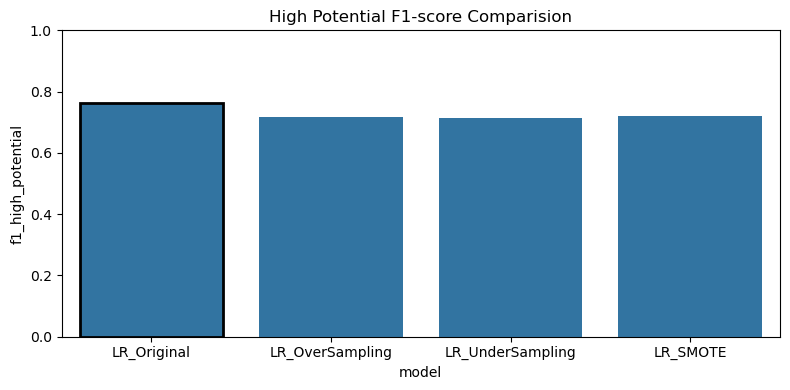

In [72]:
## Plotting the best model with recall score by highlighting the bar

best_model_lr, df_lr_f1 = compare_models_on_high_f1(y_test,preds_lr,target_class=1)

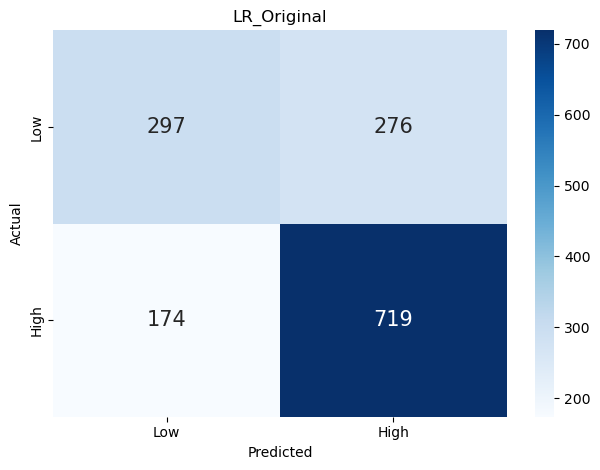

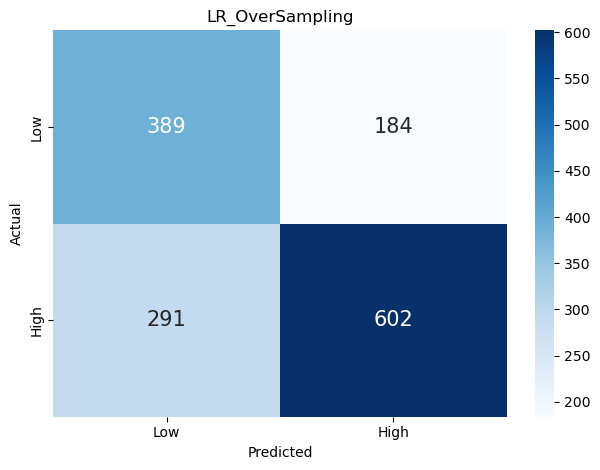

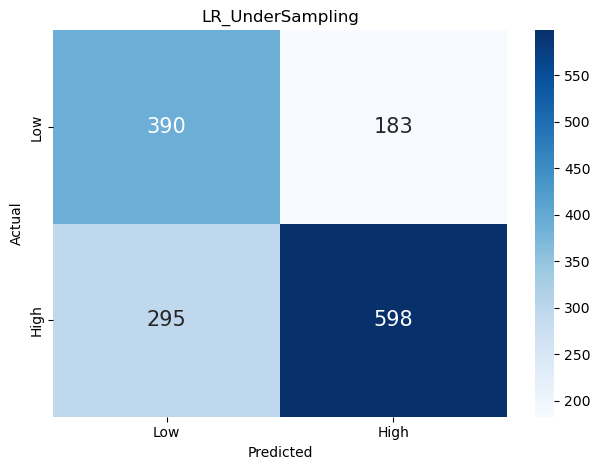

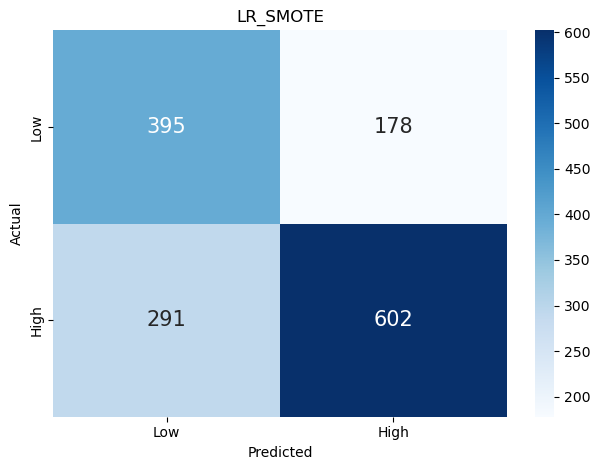

In [73]:
## Plotting the confusion matrix for Logistic Regression models

plot_confusion_matrix(y_test,preds_lr)

### Observations:

* From the plotted confusion matrix SMOTE logistic model has better classification of the target values.
* But our Main focus is on the class-1 values i.e High Potential lead values.
* So the Baseline Model line is the selected Model from this group of the models. 

#### Decision Tree Classifier 

In [74]:
## predictive id's of the models in dictionary format
preds_dt = {'DT_Original': y_pred_dtc, 'DT_Resampled': y_pred_rs_dtc, 'DT_Tuned': y_pred_best_dtc, 'DT_Resampled_Tuned':y_pred_best_rs_dtc}

In [75]:
 Models_dt = {'DT_Original': model_dtc, 'DT_Resampled': model_rs_dtc, 'DT_Tuned': best_dtc, 'DT_Resampled_Tuned':best_rs_dtc}

In [76]:
df_reports_dtc = build_classification_reports(y_test,preds_dt)
df_reports_dtc

,index,precision,recall,f1-score,support,model
0,0,0.587662,0.631763,0.608915,573.000000,DT_Original
1,1,0.751765,0.715566,0.733219,893.000000,DT_Original
2,accuracy,0.682810,0.682810,0.682810,0.682810,DT_Original
3,macro avg,0.669714,0.673664,0.671067,1466.000000,DT_Original
4,weighted avg,0.687624,0.682810,0.684633,1466.000000,DT_Original
5,0,0.779070,0.935428,0.850119,573.000000,DT_Resampled
6,1,0.952442,0.829787,0.886894,893.000000,DT_Resampled
7,accuracy,0.871078,0.871078,0.871078,0.871078,DT_Resampled
8,macro avg,0.865756,0.882607,0.868507,1466.000000,DT_Resampled
9,weighted avg,0.884678,0.871078,0.872520,1466.000000,DT_Resampled


In [77]:
## comparing the best evaluation metrics via a DataFrame to find the highest Lead point

hp_metrics_dtc = df_reports_dtc[df_reports_dtc['index']=='1'][['model','precision','recall','f1-score']].set_index('model')
hp_metrics_dtc

,precision,recall,f1-score
model,,,
DT_Original,0.751765,0.715566,0.733219
DT_Resampled,0.952442,0.829787,0.886894
DT_Tuned,0.768519,0.743561,0.755834
DT_Resampled_Tuned,0.865482,0.763718,0.811422


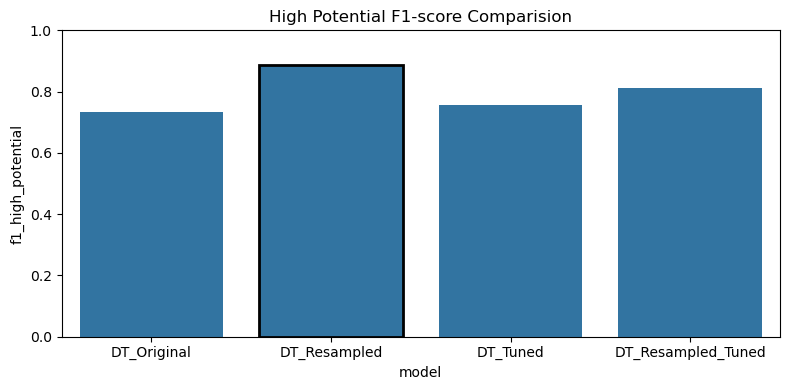

In [78]:
## Plotting the best model with recall score by highlighting the bar

best_model_dtc, df_dtc_f1 = compare_models_on_high_f1(y_test,preds_dt,target_class=1)

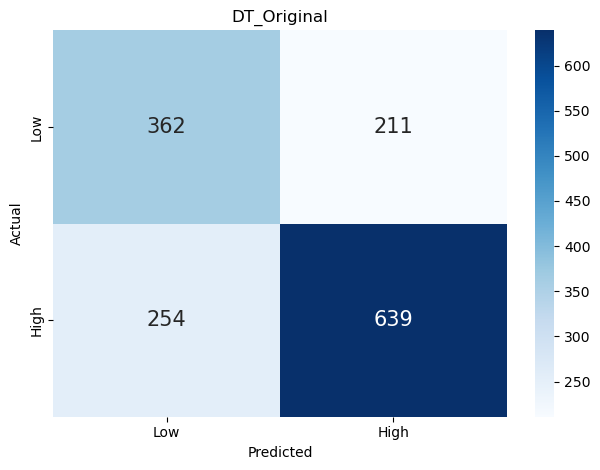

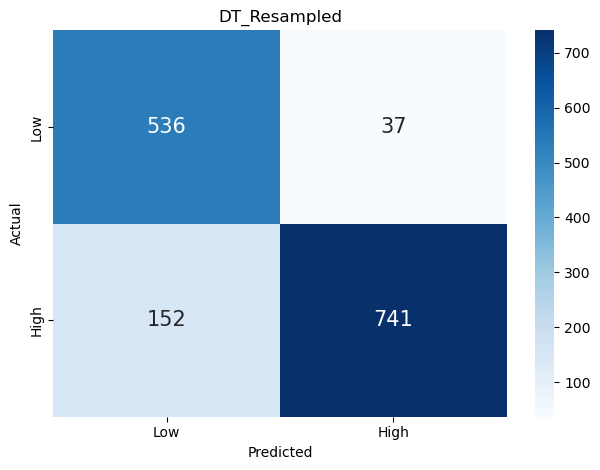

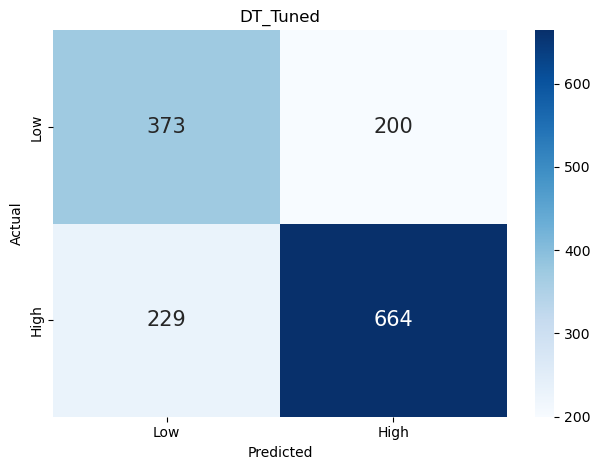

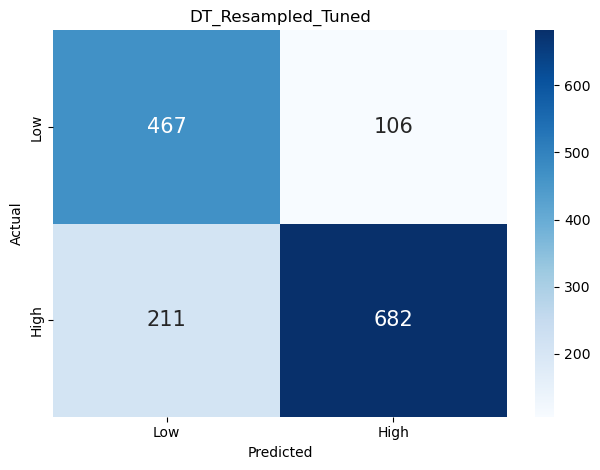

In [79]:
## Plotting the confusion matrix for Decision Tree models

plot_confusion_matrix(y_test,preds_dt)

### Obserations:
* From the classification report and as well as from the confusion matrix, the Resampled model has the best score.
* It has the Highest distribution among the target varibales second to the Resampled+Tuned Model.
* Since we are evaluating for the Best f1-score of class-1 the selected model is Resampled Decision Tree Classifier.

#### Random Forest Classifier

In [80]:
## predictive ID's for the Random Classifier models in dictionary format

preds_rf = {'RF_Original': y_pred_rf, 'RF_Resampled': y_pred_rf_rs, 'RF_Tuned': y_pred_rf_hp, 'RF_Resampled_Tuned':y_pred_rf_hp_rs}

In [81]:
Models_rf = {'RF_Original': model_rf, 'RF_Resampled': model_rf_rs, 'RF_Tuned': model_rf_hp, 'RF_Resampled_Tuned':model_rf_hp_rs}

In [82]:
df_reports_rf = build_classification_reports(y_test,preds_rf)
df_reports_rf

,index,precision,recall,f1-score,support,model
0,0,0.669405,0.568935,0.615094,573.000000,RF_Original
1,1,0.747702,0.819709,0.782051,893.000000,RF_Original
2,accuracy,0.721692,0.721692,0.721692,0.721692,RF_Original
3,macro avg,0.708553,0.694322,0.698573,1466.000000,RF_Original
4,weighted avg,0.717099,0.721692,0.716795,1466.000000,RF_Original
5,0,0.735338,0.853403,0.789984,573.000000,RF_Resampled
6,1,0.895131,0.802912,0.846517,893.000000,RF_Resampled
7,accuracy,0.822647,0.822647,0.822647,0.822647,RF_Resampled
8,macro avg,0.815235,0.828157,0.818250,1466.000000,RF_Resampled
9,weighted avg,0.832675,0.822647,0.824421,1466.000000,RF_Resampled


In [83]:
df_reports_rf.index.unique()

RangeIndex(start=0, stop=20, step=1)

In [84]:
df_reports_rf.head()
df_reports_rf.columns

Index(['index', 'precision', 'recall', 'f1-score', 'support', 'model'], dtype='object')

In [85]:
## comparing the best evaluation metrics via a DataFrame to find the highest Lead point

hp_metrics_rf = df_reports_rf[df_reports_rf['index']=='1'][['model','precision','recall','f1-score']].set_index('model')
hp_metrics_rf

,precision,recall,f1-score
model,,,
RF_Original,0.747702,0.819709,0.782051
RF_Resampled,0.895131,0.802912,0.846517
RF_Tuned,0.753830,0.826428,0.788462
RF_Resampled_Tuned,0.916058,0.843225,0.878134


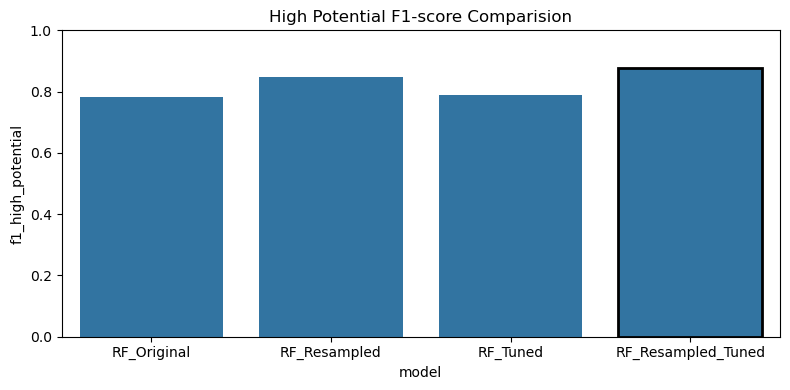

In [86]:
## Plotting the best model with recall score by highlighting the bar

best_model_rf, df_rf_f1 = compare_models_on_high_f1(y_test,preds_rf,target_class=1)

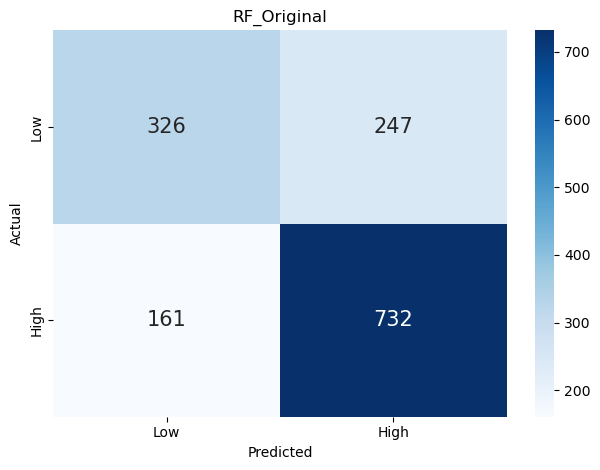

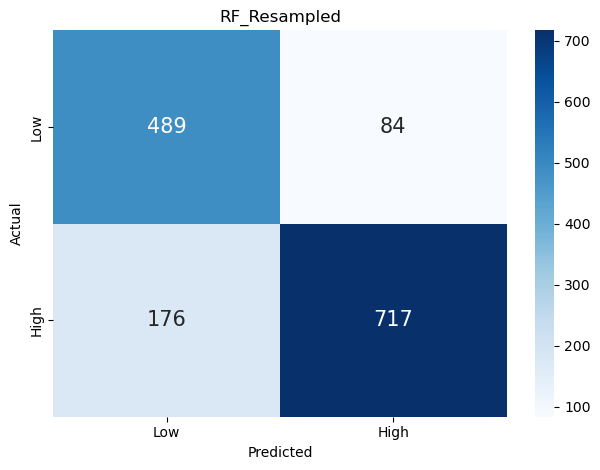

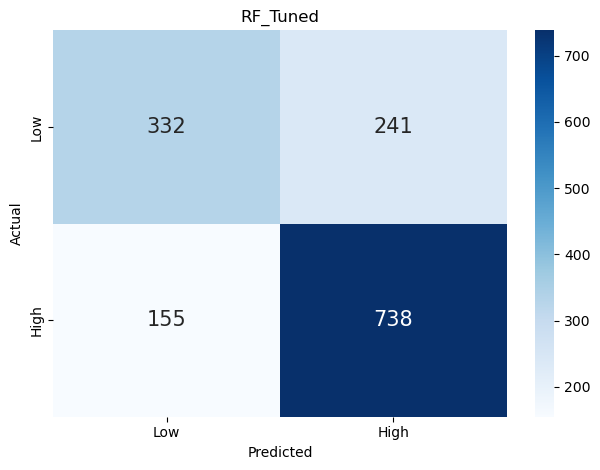

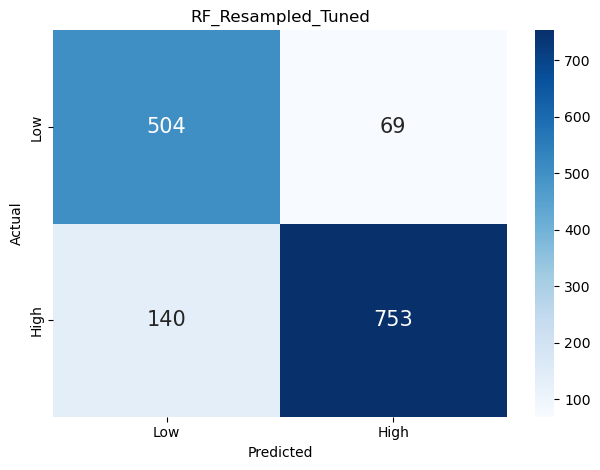

In [87]:
## Plotting the confusion matrix for Decision Tree models

plot_confusion_matrix(y_test,preds_rf)

#### Observations:

* As similar to the Decision Tree Classifier, RandomForestClassifier as also performed similarly with the given models.
* Hence the Resampled Model of RandomForestClassifier is selected.

#### XGB Classifier

In [88]:
## predictive ID's for the Random Classifier models in dictionary format

preds_xgb = {'XGB_Original': y_pred_xgb, 'XGB_Resampled': y_pred_xgb_rs, 'XGB_Tuned': y_pred_best_xgb, 'XGB_Resampled_Tuned':y_pred_xgb_rs}

In [89]:
Models_xgb = {'XGB_Original': model_xgb, 'XGB_Resampled': model_xgb_rs, 'XGB_Tuned': best_xgb, 'XGB_Resampled_Tuned':best_xgb_rs}

In [90]:
df_reports_xgb = build_classification_reports(y_test,preds_xgb)
df_reports_xgb

,index,precision,recall,f1-score,support,model
0,0,0.663405,0.591623,0.625461,573.000000,XGB_Original
1,1,0.754974,0.807391,0.780303,893.000000,XGB_Original
2,accuracy,0.723056,0.723056,0.723056,0.723056,XGB_Original
3,macro avg,0.709189,0.699507,0.702882,1466.000000,XGB_Original
4,weighted avg,0.719183,0.723056,0.719782,1466.000000,XGB_Original
5,0,0.735795,0.452007,0.560000,573.000000,XGB_Resampled
6,1,0.718133,0.895857,0.797210,893.000000,XGB_Resampled
7,accuracy,0.722374,0.722374,0.722374,0.722374,XGB_Resampled
8,macro avg,0.726964,0.673932,0.678605,1466.000000,XGB_Resampled
9,weighted avg,0.725036,0.722374,0.704494,1466.000000,XGB_Resampled


In [91]:
## comparing the best evaluation metrics via a DataFrame to find the highest Lead point

hp_metrics_xgb = df_reports_xgb[df_reports_xgb['index']=='1'][['model','precision','recall','f1-score']].set_index('model')
hp_metrics_xgb

,precision,recall,f1-score
model,,,
XGB_Original,0.754974,0.807391,0.780303
XGB_Resampled,0.718133,0.895857,0.797210
XGB_Tuned,0.718133,0.895857,0.797210
XGB_Resampled_Tuned,0.718133,0.895857,0.797210


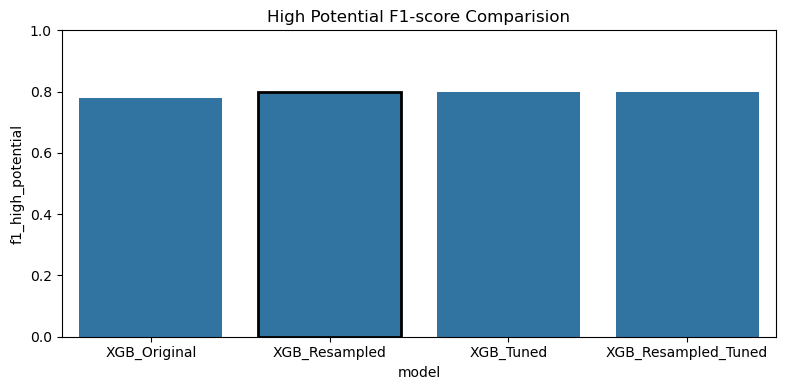

In [92]:
## Plotting the best model with recall score by highlighting the bar

best_model_xgb, df_xgb_f1 = compare_models_on_high_f1(y_test,preds_xgb,target_class=1)

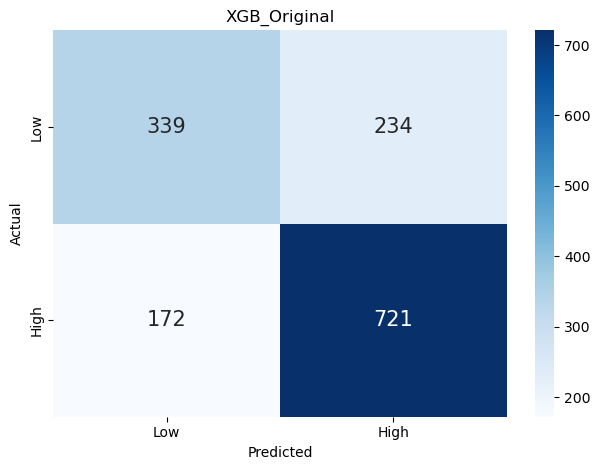

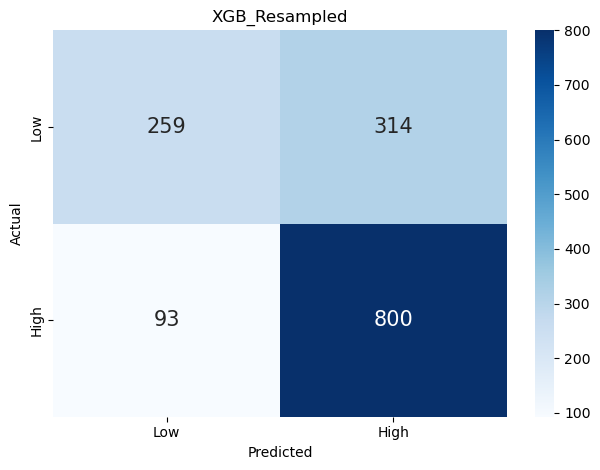

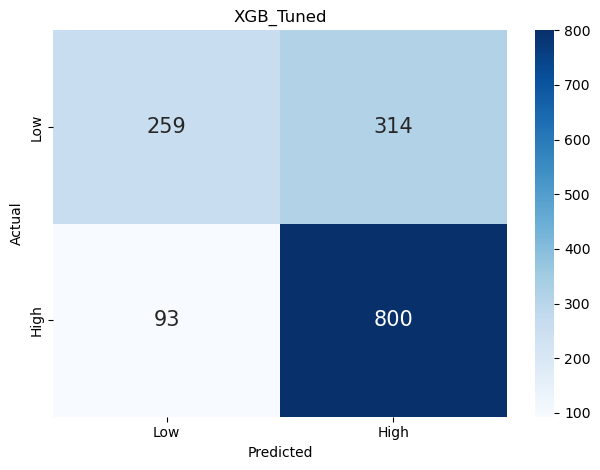

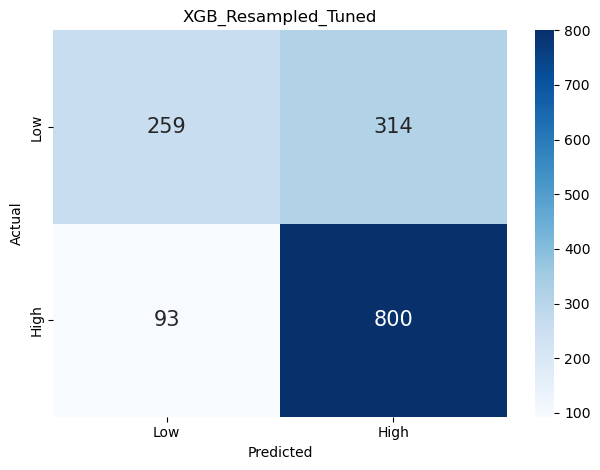

In [93]:
## Plotting the confusion matrix for Decision Tree models

plot_confusion_matrix(y_test,preds_xgb)

#### Observations:

* In the case of XGB models there is no progress of improvision and yielded same results in the three models.
* SO any model could be considered except for the Base XGB model.

### Final Evaluation of Classification Report

In [94]:
all_dfs = {
    'Logistic Regression': df_lr_f1,
    'Decision Tree' : df_dtc_f1,
    'Random Forest': df_rf_f1,
    'XGBoost': df_xgb_f1
}

# Initialize dictionary to store final evaluation
final_model_evaluation = {}

for model_type, df_eval in all_dfs.items():
    # Get the best model name (highest F1 for High Potential)
    best_model = df_eval.loc[df_eval['f1_high_potential'].idxmax(), 'model']
    best_f1 = df_eval['f1_high_potential'].max()
    
    # Store in dictionary
    final_model_evaluation[model_type] = {
        'best_model_name': best_model,
        'f1_high_potential': best_f1
    }

# Convert dictionary to DataFrame for easy viewing
df_final_evaluation = pd.DataFrame(final_model_evaluation).T.reset_index().rename(columns={'index':'Model_Type'})
df_final_evaluation

,Model_Type,best_model_name,f1_high_potential
0,Logistic Regression,LR_Original,0.761653
1,Decision Tree,DT_Resampled,0.886894
2,Random Forest,RF_Resampled_Tuned,0.878134
3,XGBoost,XGB_Resampled,0.79721


## Model Validation

#### Feature Importance(Technical Validation)

In [95]:
# function to create a gini index to plot to visulaize the feature_names and contributions to their models.

def plot_gini_importance(model,feature_names,model_names,top_k = 5):
    importances = model.feature_importances_
    sorted_idx = np.argsort(importances)[-top_k:]

    plt.figure(figsize=(6,5))
    plt.barh(
        np.array(feature_names)[sorted_idx],
        importances[sorted_idx]
    )
    plt.xlabel("Gini Importance")
    plt.title(f'{model_name} - Gini-Based Feature Importance')
    plt.tight_layout()
    plt.show()

In [96]:
best_models={
    model_type:details['best_model_name']
    for model_type,details in final_model_evaluation.items()
}

In [97]:
best_models

{'Logistic Regression': 'LR_Original',
 'Decision Tree': 'DT_Resampled',
 'Random Forest': 'RF_Resampled_Tuned',
 'XGBoost': 'XGB_Resampled'}

In [98]:
all_models = {}
all_models.update(Models_lr)
all_models.update(Models_dt)
all_models.update(Models_rf)
all_models.update(Models_xgb)

In [99]:
def plot_lr_importance(model, feature_names, model_name, top_k=10):
    coef_importance = np.abs(model.coef_[0])
    sorted_idx = np.argsort(coef_importance)[-top_k:]

    plt.figure(figsize=(6, 5))
    plt.barh(
        feature_names[sorted_idx],
        coef_importance[sorted_idx]
    )
    plt.xlabel("Absolute Coefficient Value")
    plt.title(f"{model_name} – Logistic Regression Importance")
    plt.tight_layout()
    plt.show()

def plot_gini_importance(model, feature_names, model_name, top_k=10):
    importances = model.feature_importances_
    sorted_idx = np.argsort(importances)[-top_k:]

    plt.figure(figsize=(6, 5))
    plt.barh(
        feature_names[sorted_idx],
        importances[sorted_idx]
    )
    plt.xlabel("Gini Importance")
    plt.title(f"{model_name} – Feature Importance")
    plt.tight_layout()
    plt.show()


Model Type: Logistic Regression
Best Model: LR_Original


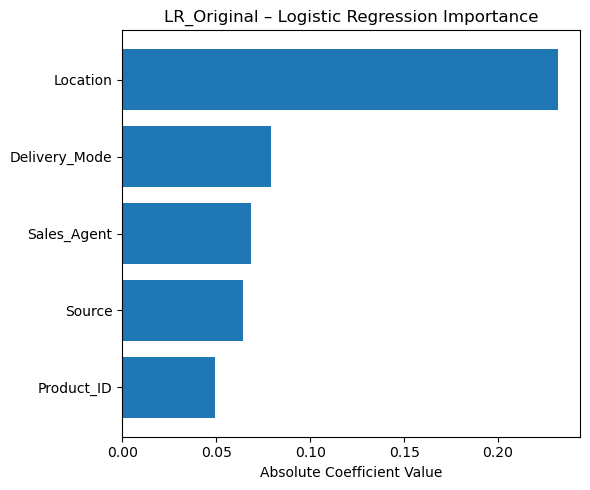


Model Type: Decision Tree
Best Model: DT_Resampled


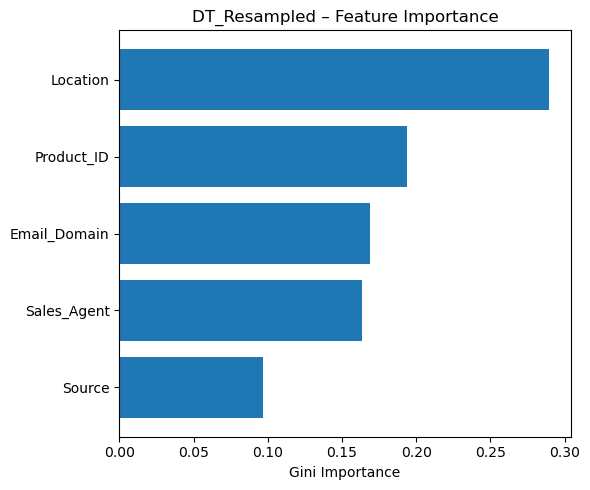


Model Type: Random Forest
Best Model: RF_Resampled_Tuned


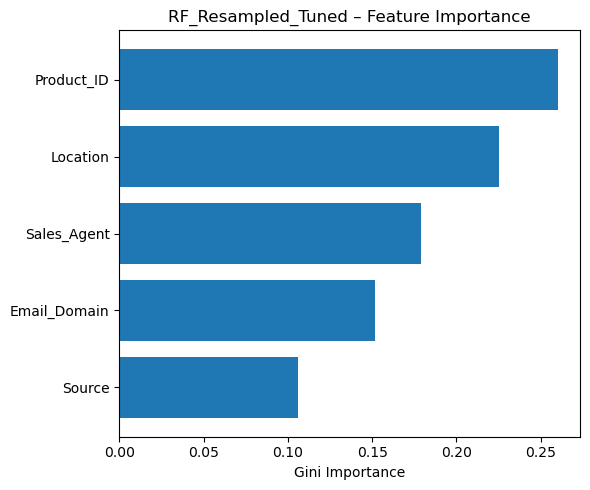


Model Type: XGBoost
Best Model: XGB_Resampled


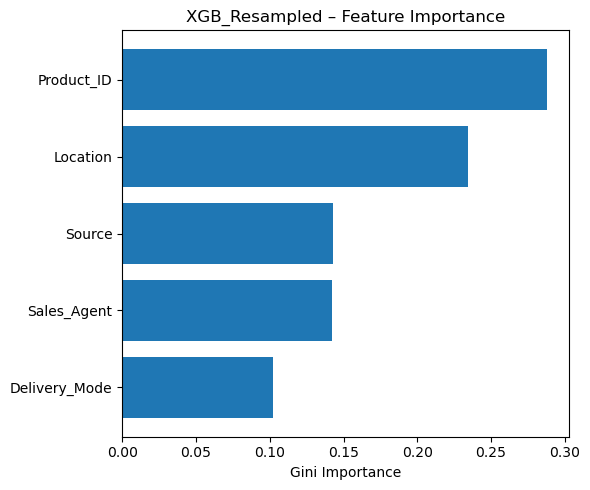

In [100]:
for model_type, best_model_name in best_models.items():

    model = all_models[best_model_name]

    print(f"\nModel Type: {model_type}")
    print(f"Best Model: {best_model_name}")

    # Logistic Regression
    if model_type == "Logistic Regression":
        plot_lr_importance(
            model=model,
            feature_names=x_train.columns.values,
            model_name=best_model_name,
            top_k=5
        )

    # Decision Tree,Random Forest, XGBoost -> Gini index
    else:
        plot_gini_importance(
            model=model,
            feature_names=x_train.columns.values,
            model_name=best_model_name,
            top_k=5
        )

### Observations:

* The performed evaluation is for to identify how often were the features of the dataset are used in the splits.
* This will give us a rough idea about how the best models have used the presented features to derive the results of their own.
* High importance does not mean a feature causes the outcome.
* It only indicated the predictive contribution under the model's assumption.
* This was not an exact way to identify the best model as it provides different operatives based on different models.
* Logisitic Regression requires scaling and hence the their co-efficents are interpreted using absolute values for importance.
* The other models used gini index or entropy, in our case is gini index.
* Hence this is only used for interpretation purpose for the context of the models not as vindictive measure to decide the best model.

### Final Model Selection

In [101]:
best_row = df_final_evaluation.loc[df_final_evaluation['f1_high_potential'].idxmax()]

best_row

Model_Type           Decision Tree
best_model_name       DT_Resampled
f1_high_potential         0.886894
Name: 1, dtype: object

In [102]:
print(classification_report(y_test,y_pred_rs_dtc))

              precision    recall  f1-score   support

           0       0.78      0.94      0.85       573
           1       0.95      0.83      0.89       893

    accuracy                           0.87      1466
   macro avg       0.87      0.88      0.87      1466
weighted avg       0.88      0.87      0.87      1466



In [103]:
cm_final_model = confusion_matrix(y_test,y_pred_rs_dtc)
cm_final_model

array([[536,  37],
       [152, 741]], dtype=int64)

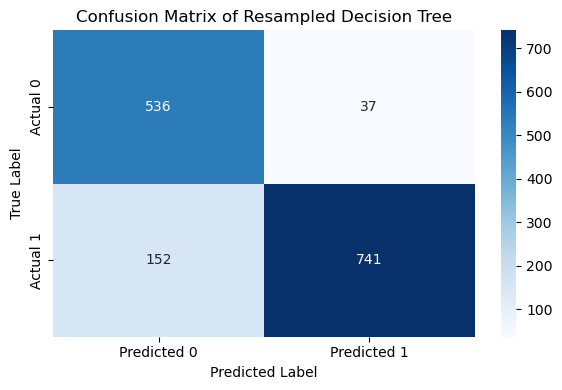

In [104]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_final_model,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of Resampled Decision Tree')
plt.savefig("confusion_matrix_dt.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

# Final Report

#### **A Brief Summary**:
* Overview:
    * FicZon is highly dependent on a few digital channels for lead generation.
    * The goal of the project was to define a Model to predict High Potential Leads.
    * The reason was everything was handled manually and needed assistance to classify the leads.
    * The company wanted to focous their interest to create a means to identify the leads accurately.
    * This would help them to classify and get insights on how they are gonna utilize them for future purposes.
    * The Company has been facing some downleads and wanted to improve their business stratgy.
    * Hence this project was generated to cater to the needs of FicZon.

#### **Project's Essence**:
* Aim:
    * To create a model which can predict High Potential Leads without losing the data.
    * High-cardinality sources were detected in the data file.
    * Data Insights were drawn from the features in the data.
    * Categorizing of the leads were done into two classes to get Low-Cardinallity.
    * Location and Mode of delivery were the two features which had most contributions to the sales.
    * The foreign countries were providing highest sales when compared to the domestic market.
    * We observed that Sales leads were assigned the cases randomly regardless of the priority in clasess.
    * Most of the leads were generated through the source of calls according to the data.
    * Website and live=chat also contributed more for lead generations.
    * Based on the Exploratory Analysis the suitable models were selected.
    * There was class imbalance in the data for the leads with Low Potential as the highest value.
    * Class Imblance was later handled by the SMOTE technique which uses synthetically generating values from the minority class.
    * This approach yielded the best results and was used for advanced models.
    * Among the Tree models and the ensemble models, due to the requirement perspective we foucused only on the Prediction of the High Potentail lead accurately.
    * This implies we focused only on one class results but not the entire target feature
    * Thus even after tuning the model, it considered only the cases from the High leads so it provided moderate results.
    * From the confusion matrix we can observe how the distribution was dispersed among the classes.
    * Ultimately aftering comparing and evaluation we reached the conclusion.
    * Using classification reports and F1-score as the metric, we found the best solution model for this project
    * Decision Tree with SMOTE sampling has yielded the best results and met the criteria of our requirements for the desired model.

#### **Challenges Faced**:
* Initial Stages:
    * The data was procured and established via mysql to the document.
    * Product_ID: 5,9, 15, 18, 19 and 27 IDs accounts for about 90% of the sales
    * High cardinality as a result of several products offered by FizCon. Low sales count product should be consider for merging as 'other' or 'low sales IDs'
    * Source:
        * Call, live chat direct and website sources account to a very significant count of sale
        * high cardinality mainly influence by variation in unique values e.g. live chats is disaggregated as live chat-direct, live chat-google organic, live chat - PPC, etc . These variations will require consolidation to reduce high cardinality
    * Sales Agent: Sales_Agent4,Sales_Agent5 and Sales_Agent11 each made over 1000 sales Sales_Agent3, Sales_Agent7 and Sales_Agent9 made sales above 600 but below 1000.

* EDA(Exploratory Data Analysis):
    * The high cardinality of most categorical variable... It makes difficult for the model to learn and negatively impact on model accuracy. The team opted to compress and merge values of features with high cardinality

* Model Building:
    * The models were focused to target only one type of class instead of both.
    * Hence the models were heavily leaned towards that specific class.
    * This influenced the result generation in a most significant way.
    * Even though we performed tuning the reason for not yielding better results may lie in the distribution and how it influenced the feature selection of the model.
    * Finally the model was selected in a bias way rather than optimal method since this was our requirement.

#### **Final Model Attributes**:

## Confusion Matrix – Best Performing Model
![Confusion Matrix](confusion_matrix_dt.png)

* Observations:
    * The model corretly classified 741 high potential instances as High Potential Leads(True Positive) and 536 Low - potentail instances as Low potentail Leads(True Negatives).
    * There are 37 false positive instances which were incorrectly flagged as high potential.
    * The model produced 152 false negatives meaning high-potential instanves were missed.
    * Considering these factors it demonstrated very High Precision for the High Potential class.
    * This is important in the perspecive of the business scenarios where false positives are costly.
    * Which gives us insight that this model with resulting F1-score(~0.887) is well-suited for scenarios where confidence in high-potential predictions is critical, while accepting a moderate risk of missed opportunities.



### **Future Improvements**:
* Ideas:
    * The project has a lot of scope for improvement that can be tailored for further enhancements of this project.
    * Instead of single instance focus we could try the entire instances to refine the precison and recall.
    * Focusing on sole instance can get only upto some extent of the results.
    * We could try using SHAP for getting precised business-agnostic results.
    * With SHAP we can find the feature contributions and even provide more insights to the case.
    * For Example how to assign certain High leads to a specific Sales agent.
    * With further discussions from the Clients, we could derive much better results.